In [1]:
import os
import shutil
import random
from pathlib import Path

# =========================
# PATHS
# =========================
BASE_DIR = Path(r"C:/Users/asus/Downloads/archive(2)/FaceForensics++_C23")
OUT_DIR = Path(r"C:/deepfake_small")

FAKE_TYPES = ["Deepfakes", "FaceSwap", "Face2Face", "NeuralTextures", "FaceShifter"]

REAL_SRC = BASE_DIR / "original"
REAL_OUT = OUT_DIR / "original"

random.seed(42)

# =========================
# CREATE OUTPUT FOLDERS
# =========================
REAL_OUT.mkdir(parents=True, exist_ok=True)

for ftype in FAKE_TYPES:
    (OUT_DIR / ftype).mkdir(parents=True, exist_ok=True)

# =========================
# OPTIONAL: CLEAR OLD FILES
# =========================
def clear_folder(folder: Path):
    for f in folder.iterdir():
        if f.is_file():
            f.unlink()

clear_folder(REAL_OUT)
for ftype in FAKE_TYPES:
    clear_folder(OUT_DIR / ftype)

print("Old files cleared from output folders.")

# =========================
# HELPER TO GET MP4 FILES
# =========================
def get_mp4_files(folder: Path):
    return sorted([p for p in folder.rglob("*.mp4") if p.is_file()])

# =========================
# FAKE: 20 FROM EACH TYPE
# TOTAL = 100 FAKE
# =========================
fake_total = 0

for ftype in FAKE_TYPES:
    src_folder = BASE_DIR / ftype
    out_folder = OUT_DIR / ftype

    videos = get_mp4_files(src_folder)

    if len(videos) < 20:
        raise ValueError(f"Not enough videos in {ftype}. Found {len(videos)}, need 20.")

    selected = random.sample(videos, 20)

    for video in selected:
        dst = out_folder / video.name
        shutil.copy2(video, dst)
        fake_total += 1

    print(f"✔ {ftype} done | Copied 20 videos")

# =========================
# REAL: 100 VIDEOS
# =========================
real_videos = get_mp4_files(REAL_SRC)

if len(real_videos) < 100:
    raise ValueError(f"Not enough real videos. Found {len(real_videos)}, need 100.")

selected_real = random.sample(real_videos, 100)

for video in selected_real:
    dst = REAL_OUT / video.name
    shutil.copy2(video, dst)

print(f"✔ Real videos done | Copied {len(selected_real)} videos")

# =========================
# FINAL SUMMARY
# =========================
print("\nFINAL DATASET READY")
print("Fake videos copied:", fake_total)
print("Real videos copied:", len(selected_real))
print("Output folder:", OUT_DIR)

Old files cleared from output folders.
✔ Deepfakes done | Copied 20 videos
✔ FaceSwap done | Copied 20 videos
✔ Face2Face done | Copied 20 videos
✔ NeuralTextures done | Copied 20 videos
✔ FaceShifter done | Copied 20 videos
✔ Real videos done | Copied 100 videos

FINAL DATASET READY
Fake videos copied: 100
Real videos copied: 100
Output folder: C:\deepfake_small


In [3]:
import os
import cv2
import json
import copy
import random
import warnings
import time
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import List, Tuple, Optional

import numpy as np
import pandas as pd
from PIL import Image

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore")


# =========================================================
# CONFIG
# =========================================================
@dataclass
class CFG:
    DATA_ROOT: str = r"C:/deepfake_small"
    OUTPUT_DIR: str = r"C:/deepfake_final_output"

    IMG_SIZE: int = 224
    SEQ_LEN: int = 12
    MAX_DECODE_FRAMES: int = 48

    BATCH_SIZE: int = 2
    EPOCHS: int = 30
    LR: float = 1e-4
    WEIGHT_DECAY: float = 1e-4
    NUM_WORKERS: int = 0
    PATIENCE: int = 8
    SEED: int = 42

    TRAIN_RATIO: float = 0.70
    VAL_RATIO: float = 0.15
    TEST_RATIO: float = 0.15

    FREEZE_BACKBONE_EPOCHS: int = 2
    DROPOUT: float = 0.30
    HIDDEN_SIZE: int = 128

    MAX_VIDEOS_PER_CLASS: Optional[int] = None
    VIDEO_EXTS: Tuple[str, ...] = (".mp4", ".avi", ".mov", ".mkv")
    BALANCE_BINARY_CLASSES: bool = True
    BALANCE_FAKE_SUBTYPES: bool = True

    USE_FACE_CROP: bool = True
    ENABLE_FRAME_CACHE: bool = True


cfg = CFG()
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)


# =========================================================
# SEED
# =========================================================
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(cfg.SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


# =========================================================
# FACE DETECTOR
# =========================================================
def get_face_detector():
    cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    if os.path.exists(cascade_path):
        return cv2.CascadeClassifier(cascade_path)
    return None


FACE_DETECTOR = get_face_detector() if cfg.USE_FACE_CROP else None


def crop_face_bgr(frame_bgr: np.ndarray) -> np.ndarray:
    if FACE_DETECTOR is None:
        return frame_bgr

    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    faces = FACE_DETECTOR.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(40, 40),
    )
    if len(faces) == 0:
        return frame_bgr

    x, y, w, h = max(faces, key=lambda b: b[2] * b[3])
    pad = int(0.15 * max(w, h))
    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(frame_bgr.shape[1], x + w + pad)
    y2 = min(frame_bgr.shape[0], y + h + pad)

    face = frame_bgr[y1:y2, x1:x2]
    return face if face.size > 0 else frame_bgr


# =========================================================
# DATA INDEX
# =========================================================
def list_videos(folder: Path, label: int, max_count: Optional[int] = None) -> List[dict]:
    files = [p for p in folder.rglob("*") if p.suffix.lower() in cfg.VIDEO_EXTS]
    files = sorted(files)
    if max_count is not None:
        files = files[:max_count]

    rows = []
    for p in files:
        rows.append(
            {
                "video_path": str(p),
                "label": int(label),
                "class_name": "fake" if label == 1 else "real",
                "video_id": p.stem,
                "group_id": p.stem,
            }
        )
    return rows


def build_index(data_root: str) -> pd.DataFrame:
    root = Path(data_root)
    real_dir = root / "original"
    fake_dirs = [
        root / "Deepfakes",
        root / "Face2Face",
        root / "FaceShifter",
        root / "FaceSwap",
        root / "NeuralTextures",
    ]

    if not real_dir.exists():
        raise FileNotFoundError("Expected real folder: DATA_ROOT/original")

    existing_fake_dirs = [p for p in fake_dirs if p.exists()]
    if not existing_fake_dirs:
        raise FileNotFoundError(
            "No fake folders found. Expected one or more of: "
            "Deepfakes, Face2Face, FaceShifter, FaceSwap, NeuralTextures"
        )

    real_rows = list_videos(real_dir, label=0, max_count=cfg.MAX_VIDEOS_PER_CLASS)
    for row in real_rows:
        row["manipulation_type"] = "original"

    fake_blocks = []
    for fake_dir in existing_fake_dirs:
        fake_rows = list_videos(fake_dir, label=1, max_count=cfg.MAX_VIDEOS_PER_CLASS)
        for row in fake_rows:
            row["manipulation_type"] = fake_dir.name
        fake_blocks.append(fake_rows)

    if cfg.BALANCE_BINARY_CLASSES:
        n_real = len(real_rows)
        if n_real == 0:
            raise ValueError("No real videos found.")

        if cfg.BALANCE_FAKE_SUBTYPES:
            per_fake_type = max(1, n_real // len(fake_blocks))
            balanced_fake_rows = []
            for fake_rows in fake_blocks:
                if len(fake_rows) == 0:
                    continue
                take_n = min(len(fake_rows), per_fake_type)
                balanced_fake_rows.extend(fake_rows[:take_n])

            remaining = n_real - len(balanced_fake_rows)
            if remaining > 0:
                leftovers = []
                for fake_rows in fake_blocks:
                    leftovers.extend(fake_rows[per_fake_type:])
                balanced_fake_rows.extend(leftovers[:remaining])
        else:
            all_fake_rows = []
            for fake_rows in fake_blocks:
                all_fake_rows.extend(fake_rows)
            balanced_fake_rows = all_fake_rows[:n_real]

        rows = real_rows + balanced_fake_rows
    else:
        rows = real_rows.copy()
        for fake_rows in fake_blocks:
            rows.extend(fake_rows)

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No videos found.")

    df = df.sample(frac=1.0, random_state=cfg.SEED).reset_index(drop=True)
    return df


def video_level_split(df: pd.DataFrame):
    splitter1 = GroupShuffleSplit(
        n_splits=1,
        test_size=(1 - cfg.TRAIN_RATIO),
        random_state=cfg.SEED,
    )
    train_idx, temp_idx = next(splitter1.split(df, y=df["label"], groups=df["group_id"]))

    train_df = df.iloc[train_idx].reset_index(drop=True)
    temp_df = df.iloc[temp_idx].reset_index(drop=True)

    relative_test = cfg.TEST_RATIO / (cfg.VAL_RATIO + cfg.TEST_RATIO)
    splitter2 = GroupShuffleSplit(
        n_splits=1,
        test_size=relative_test,
        random_state=cfg.SEED,
    )
    val_idx, test_idx = next(splitter2.split(temp_df, y=temp_df["label"], groups=temp_df["group_id"]))

    val_df = temp_df.iloc[val_idx].reset_index(drop=True)
    test_df = temp_df.iloc[test_idx].reset_index(drop=True)

    return train_df, val_df, test_df


# =========================================================
# TRANSFORMS
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


# =========================================================
# DATASET
# =========================================================
class DeepfakeVideoDataset(Dataset):
    def __init__(self, df: pd.DataFrame, seq_len: int, transform=None, enable_cache=True):
        self.df = df.reset_index(drop=True)
        self.seq_len = seq_len
        self.transform = transform
        self.enable_cache = enable_cache
        self.frame_cache = {}

    def __len__(self):
        return len(self.df)

    def _blank_frames(self):
        blank = np.zeros((cfg.IMG_SIZE, cfg.IMG_SIZE, 3), dtype=np.uint8)
        return [Image.fromarray(blank) for _ in range(self.seq_len)]

    def _safe_process_frame(self, frame):
        if frame is None:
            frame = np.zeros((cfg.IMG_SIZE, cfg.IMG_SIZE, 3), dtype=np.uint8)
        else:
            if cfg.USE_FACE_CROP:
                frame = crop_face_bgr(frame)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        return Image.fromarray(frame)

    def _load_video_frames(self, video_path: str) -> List[Image.Image]:
        if self.enable_cache and video_path in self.frame_cache:
            return self.frame_cache[video_path]

        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            frames = self._blank_frames()
            if self.enable_cache:
                self.frame_cache[video_path] = frames
            return frames

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if total_frames <= 0:
            decoded = []
            read_count = 0
            while read_count < cfg.MAX_DECODE_FRAMES:
                ok, frame = cap.read()
                if not ok:
                    break
                decoded.append(self._safe_process_frame(frame))
                read_count += 1
            cap.release()

            if len(decoded) == 0:
                frames = self._blank_frames()
            elif len(decoded) >= self.seq_len:
                idxs = np.linspace(0, len(decoded) - 1, self.seq_len, dtype=int)
                frames = [decoded[i] for i in idxs]
            else:
                frames = decoded + [decoded[-1]] * (self.seq_len - len(decoded))

            if self.enable_cache:
                self.frame_cache[video_path] = frames
            return frames

        max_scan = min(total_frames, cfg.MAX_DECODE_FRAMES)
        target_indices = np.linspace(0, max_scan - 1, self.seq_len, dtype=int)
        target_set = set(target_indices.tolist())

        frames = []
        current_idx = 0

        while current_idx < max_scan:
            ok, frame = cap.read()
            if not ok:
                break

            if current_idx in target_set:
                frames.append(self._safe_process_frame(frame))
                if len(frames) == self.seq_len:
                    break
            current_idx += 1

        cap.release()

        if len(frames) == 0:
            frames = self._blank_frames()
        elif len(frames) < self.seq_len:
            frames.extend([frames[-1]] * (self.seq_len - len(frames)))

        if self.enable_cache:
            self.frame_cache[video_path] = frames

        return frames

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        video_path = row["video_path"]
        label = float(row["label"])

        frames = self._load_video_frames(video_path)

        if self.transform is not None:
            frames = [self.transform(frame) for frame in frames]
        else:
            frames = [transforms.ToTensor()(frame) for frame in frames]

        x = torch.stack(frames, dim=0)
        y = torch.tensor(label, dtype=torch.float32)
        return x, y, video_path


# =========================================================
# MODEL
# =========================================================
class TemporalAttention(nn.Module):
    def __init__(self, feature_dim: int):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(feature_dim, feature_dim // 2),
            nn.Tanh(),
            nn.Linear(feature_dim // 2, 1),
        )

    def forward(self, x):
        scores = self.attn(x)
        weights = torch.softmax(scores, dim=1)
        context = torch.sum(weights * x, dim=1)
        return context, weights


class EfficientNetBiLSTM(nn.Module):
    def __init__(self, hidden_size=128, dropout=0.30):
        super().__init__()
        backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.backbone = backbone.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.feature_dim = 1280

        self.lstm = nn.LSTM(
            input_size=self.feature_dim,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )

        self.attn = TemporalAttention(hidden_size * 2)

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def freeze_backbone(self, freeze=True):
        for p in self.backbone.parameters():
            p.requires_grad = not freeze

    def forward(self, x):
        b, t, c, h, w = x.shape
        x = x.view(b * t, c, h, w)
        feats = self.backbone(x)
        feats = self.pool(feats).flatten(1)
        feats = feats.view(b, t, -1)

        lstm_out, _ = self.lstm(feats)
        context, attn_weights = self.attn(lstm_out)
        logits = self.head(context).squeeze(1)
        return logits, attn_weights


# =========================================================
# METRICS
# =========================================================
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (np.array(y_prob) >= threshold).astype(int)
    return {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else 0.0,
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
        "classification_report": classification_report(
            y_true, y_pred, target_names=["Real", "Fake"], zero_division=0, digits=4
        ),
    }


def run_epoch(model, loader, criterion, optimizer=None, training=True, threshold=0.5):
    if training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    all_labels = []
    all_probs = []
    all_paths = []

    start_time = time.time()

    for step, (inputs, labels, paths) in enumerate(loader, start=1):
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.set_grad_enabled(training):
            logits, _ = model(inputs)
            loss = criterion(logits, labels)

            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        probs = torch.sigmoid(logits).detach().cpu().numpy().tolist()
        running_loss += loss.item() * inputs.size(0)
        all_labels.extend(labels.detach().cpu().numpy().astype(int).tolist())
        all_probs.extend(probs)
        all_paths.extend(paths)

        if step % 10 == 0:
            print(f"{'Train' if training else 'Eval'} step {step}/{len(loader)} done")

    epoch_loss = running_loss / max(1, len(loader.dataset))
    metrics = compute_metrics(all_labels, all_probs, threshold=threshold)
    metrics["loss"] = epoch_loss
    print(f"Epoch time: {time.time() - start_time:.2f} sec")
    return metrics, all_labels, all_probs, all_paths


# =========================================================
# MAIN
# =========================================================
def main():
    print("Building dataset index...")
    df = build_index(cfg.DATA_ROOT)

    print("================ DATASET SUMMARY ================")
    print(df["class_name"].value_counts())
    print(df["manipulation_type"].value_counts())
    print("================================================")

    train_df, val_df, test_df = video_level_split(df)

    print("Split sizes:")
    print("Train:", len(train_df))
    print("Val  :", len(val_df))
    print("Test :", len(test_df))

    print("\nTrain label counts:")
    print(train_df["label"].value_counts().sort_index())
    print("\nVal label counts:")
    print(val_df["label"].value_counts().sort_index())
    print("\nTest label counts:")
    print(test_df["label"].value_counts().sort_index())

    train_df.to_csv(os.path.join(cfg.OUTPUT_DIR, "train_split.csv"), index=False)
    val_df.to_csv(os.path.join(cfg.OUTPUT_DIR, "val_split.csv"), index=False)
    test_df.to_csv(os.path.join(cfg.OUTPUT_DIR, "test_split.csv"), index=False)

    train_ds = DeepfakeVideoDataset(train_df, cfg.SEQ_LEN, train_transform, enable_cache=cfg.ENABLE_FRAME_CACHE)
    val_ds = DeepfakeVideoDataset(val_df, cfg.SEQ_LEN, val_transform, enable_cache=cfg.ENABLE_FRAME_CACHE)
    test_ds = DeepfakeVideoDataset(test_df, cfg.SEQ_LEN, val_transform, enable_cache=cfg.ENABLE_FRAME_CACHE)

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.BATCH_SIZE,
        shuffle=True,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=False,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=cfg.BATCH_SIZE,
        shuffle=False,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=False,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=cfg.BATCH_SIZE,
        shuffle=False,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=False,
    )

    neg_count = int((train_df["label"] == 0).sum())
    pos_count = int((train_df["label"] == 1).sum())
    pos_weight_value = float(neg_count / max(pos_count, 1))
    print(f"\nUsing pos_weight = {pos_weight_value:.4f}")

    model = EfficientNetBiLSTM(hidden_size=cfg.HIDDEN_SIZE, dropout=cfg.DROPOUT).to(DEVICE)
    model.freeze_backbone(True)

    pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2
    )

    best_state = None
    best_val_auc = -1.0
    best_epoch = -1
    patience_counter = 0
    history = []

    print("\nStarting training...")
    for epoch in range(1, cfg.EPOCHS + 1):
        if epoch == cfg.FREEZE_BACKBONE_EPOCHS + 1:
            print("Unfreezing backbone...")
            model.freeze_backbone(False)
            optimizer = optim.AdamW(
                model.parameters(),
                lr=cfg.LR * 0.5,
                weight_decay=cfg.WEIGHT_DECAY
            )
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode="max", factor=0.5, patience=2
            )

        train_metrics, _, _, _ = run_epoch(
            model, train_loader, criterion, optimizer=optimizer, training=True, threshold=0.5
        )

        val_metrics, _, _, _ = run_epoch(
            model, val_loader, criterion, optimizer=None, training=False, threshold=0.5
        )

        scheduler.step(val_metrics["auc"])

        history.append({
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_acc": train_metrics["accuracy"],
            "train_f1": train_metrics["f1"],
            "train_auc": train_metrics["auc"],
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["accuracy"],
            "val_f1": val_metrics["f1"],
            "val_auc": val_metrics["auc"],
        })

        print(
            f"Epoch {epoch:02d}/{cfg.EPOCHS} | "
            f"Train Loss {train_metrics['loss']:.4f} | "
            f"Train Acc {train_metrics['accuracy']:.4f} | "
            f"Train F1 {train_metrics['f1']:.4f} | "
            f"Train AUC {train_metrics['auc']:.4f} | "
            f"Val Loss {val_metrics['loss']:.4f} | "
            f"Val Acc {val_metrics['accuracy']:.4f} | "
            f"Val F1 {val_metrics['f1']:.4f} | "
            f"Val AUC {val_metrics['auc']:.4f}"
        )

        if val_metrics["auc"] > best_val_auc:
            best_val_auc = val_metrics["auc"]
            best_epoch = epoch
            patience_counter = 0
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, os.path.join(cfg.OUTPUT_DIR, "best_model.pth"))
        else:
            patience_counter += 1
            if patience_counter >= cfg.PATIENCE:
                print("Early stopping triggered.")
                break

    pd.DataFrame(history).to_csv(
        os.path.join(cfg.OUTPUT_DIR, "training_history.csv"),
        index=False
    )

    if best_state is None:
        raise RuntimeError("No best model was saved.")

    model.load_state_dict(best_state)
    print(f"\nBest epoch: {best_epoch}, Best Val AUC: {best_val_auc:.4f}")

    test_metrics, test_labels, test_probs, test_paths = run_epoch(
        model, test_loader, criterion, optimizer=None, training=False, threshold=0.5
    )

    print("\n================ TEST RESULTS ================")
    print(f"Test Loss : {test_metrics['loss']:.4f}")
    print(f"Accuracy  : {test_metrics['accuracy']:.4f}")
    print(f"Precision : {test_metrics['precision']:.4f}")
    print(f"Recall    : {test_metrics['recall']:.4f}")
    print(f"F1-score  : {test_metrics['f1']:.4f}")
    print(f"AUC       : {test_metrics['auc']:.4f}")
    print("\nClassification Report:")
    print(test_metrics["classification_report"])
    print("Confusion Matrix:")
    print(np.array(test_metrics["confusion_matrix"]))

    metrics_payload = {
        "config": asdict(cfg),
        "best_epoch": best_epoch,
        "best_val_auc": best_val_auc,
        "test_metrics": test_metrics,
    }

    with open(os.path.join(cfg.OUTPUT_DIR, "test_metrics.json"), "w", encoding="utf-8") as f:
        json.dump(metrics_payload, f, indent=2)

    pred_df = pd.DataFrame({
        "video_path": test_paths,
        "y_true": test_labels,
        "y_prob": test_probs,
        "y_pred": (np.array(test_probs) >= 0.50).astype(int),
    })
    pred_df.to_csv(os.path.join(cfg.OUTPUT_DIR, "test_predictions.csv"), index=False)

    print("\nSaved files:")
    print(os.path.join(cfg.OUTPUT_DIR, "best_model.pth"))
    print(os.path.join(cfg.OUTPUT_DIR, "training_history.csv"))
    print(os.path.join(cfg.OUTPUT_DIR, "test_metrics.json"))
    print(os.path.join(cfg.OUTPUT_DIR, "test_predictions.csv"))


if __name__ == "__main__":
    main()

C:\Users\asus\anaconda3\envs\digitml\Lib\site-packages\sklearn\utils\_param_validation.py:11: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  from scipy.sparse import csr_matrix, issparse


Using device: cpu
Building dataset index...
================ DATASET SUMMARY ================
class_name
real    100
fake    100
Name: count, dtype: int64
manipulation_type
original          100
FaceShifter        20
Face2Face          20
Deepfakes          20
FaceSwap           20
NeuralTextures     20
Name: count, dtype: int64
Split sizes:
Train: 141
Val  : 30
Test : 29

Train label counts:
label
0    69
1    72
Name: count, dtype: int64

Val label counts:
label
0    15
1    15
Name: count, dtype: int64

Test label counts:
label
0    16
1    13
Name: count, dtype: int64

Using pos_weight = 0.9583

Starting training...
Train step 10/71 done
Train step 20/71 done
Train step 30/71 done
Train step 40/71 done
Train step 50/71 done
Train step 60/71 done
Train step 70/71 done
Epoch time: 214.90 sec
Eval step 10/15 done
Epoch time: 37.56 sec
Epoch 01/30 | Train Loss 0.6839 | Train Acc 0.4539 | Train F1 0.2222 | Train AUC 0.3684 | Val Loss 0.6687 | Val Acc 0.6667 | Val F1 0.5000 | Val AUC 0.8

In [30]:
import os
import cv2
import json
import copy
import random
import warnings
import time
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import List, Tuple, Optional

import numpy as np
import pandas as pd
from PIL import Image

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

warnings.filterwarnings("ignore")


@dataclass
class CFG:
    DATA_ROOT: str = r"C:/deepfake_small"
    OUTPUT_DIR: str = r"C:/deepfake_small_output_fast"

    IMG_SIZE: int = 160
    SEQ_LEN: int = 8
    BATCH_SIZE: int = 2
    EPOCHS: int = 10
    LR: float = 2e-4
    WEIGHT_DECAY: float = 1e-4
    NUM_WORKERS: int = 0
    PATIENCE: int = 3
    SEED: int = 42

    TRAIN_RATIO: float = 0.70
    VAL_RATIO: float = 0.15
    TEST_RATIO: float = 0.15

    USE_FP16: bool = False
    FREEZE_BACKBONE_EPOCHS: int = 1
    DROPOUT: float = 0.15
    HIDDEN_SIZE: int = 128
    POS_CLASS_WEIGHT: float = 1.0

    MAX_VIDEOS_PER_CLASS: Optional[int] = None
    VIDEO_EXTS: Tuple[str, ...] = (".mp4", ".avi", ".mov", ".mkv")
    BALANCE_BINARY_CLASSES: bool = True
    BALANCE_FAKE_SUBTYPES: bool = True

    USE_FACE_CROP: bool = False
    ENABLE_FRAME_CACHE: bool = True
    MAX_DECODE_FRAMES: int = 32


cfg = CFG()
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(cfg.SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


def get_face_detector():
    cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    if os.path.exists(cascade_path):
        return cv2.CascadeClassifier(cascade_path)
    return None


FACE_DETECTOR = get_face_detector() if cfg.USE_FACE_CROP else None


def crop_face_bgr(frame_bgr: np.ndarray) -> np.ndarray:
    if FACE_DETECTOR is None:
        return frame_bgr

    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    faces = FACE_DETECTOR.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(40, 40),
    )

    if len(faces) == 0:
        return frame_bgr

    x, y, w, h = max(faces, key=lambda b: b[2] * b[3])
    pad = int(0.15 * max(w, h))
    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(frame_bgr.shape[1], x + w + pad)
    y2 = min(frame_bgr.shape[0], y + h + pad)
    face = frame_bgr[y1:y2, x1:x2]
    return face if face.size > 0 else frame_bgr


def list_videos(folder: Path, label: int, max_count: Optional[int] = None) -> List[dict]:
    files = [p for p in folder.rglob("*") if p.suffix.lower() in cfg.VIDEO_EXTS]
    files = sorted(files)
    if max_count is not None:
        files = files[:max_count]

    rows = []
    for p in files:
        rows.append(
            {
                "video_path": str(p),
                "label": int(label),
                "class_name": "fake" if label == 1 else "real",
                "video_id": p.stem,
                "group_id": p.stem,
            }
        )
    return rows


def build_index(data_root: str) -> pd.DataFrame:
    root = Path(data_root)
    real_dir = root / "original"
    fake_dirs = [
        root / "Deepfakes",
        root / "Face2Face",
        root / "FaceShifter",
        root / "FaceSwap",
        root / "NeuralTextures",
    ]

    if not real_dir.exists():
        raise FileNotFoundError("Expected real folder: DATA_ROOT/original")

    existing_fake_dirs = [p for p in fake_dirs if p.exists()]
    if not existing_fake_dirs:
        raise FileNotFoundError(
            "None of the fake folders were found. Expected one or more of: "
            "Deepfakes, Face2Face, FaceShifter, FaceSwap, NeuralTextures"
        )

    real_rows = list_videos(real_dir, label=0, max_count=cfg.MAX_VIDEOS_PER_CLASS)
    for row in real_rows:
        row["manipulation_type"] = "original"

    fake_blocks = []
    for fake_dir in existing_fake_dirs:
        fake_rows = list_videos(fake_dir, label=1, max_count=cfg.MAX_VIDEOS_PER_CLASS)
        for row in fake_rows:
            row["manipulation_type"] = fake_dir.name
        fake_blocks.append(fake_rows)

    if cfg.BALANCE_BINARY_CLASSES:
        n_real = len(real_rows)
        if n_real == 0:
            raise ValueError("No real videos found in DATA_ROOT/original")

        if cfg.BALANCE_FAKE_SUBTYPES:
            per_fake_type = max(1, n_real // len(fake_blocks))
            balanced_fake_rows = []

            for fake_rows in fake_blocks:
                if len(fake_rows) == 0:
                    continue
                take_n = min(len(fake_rows), per_fake_type)
                balanced_fake_rows.extend(fake_rows[:take_n])

            remaining = n_real - len(balanced_fake_rows)
            if remaining > 0:
                leftovers = []
                for fake_rows in fake_blocks:
                    leftovers.extend(fake_rows[per_fake_type:])
                balanced_fake_rows.extend(leftovers[:remaining])
        else:
            all_fake_rows = []
            for fake_rows in fake_blocks:
                all_fake_rows.extend(fake_rows)
            balanced_fake_rows = all_fake_rows[:n_real]

        rows = real_rows + balanced_fake_rows
    else:
        rows = real_rows.copy()
        for fake_rows in fake_blocks:
            rows.extend(fake_rows)

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No videos found. Check DATA_ROOT and extensions.")

    df = df.sample(frac=1.0, random_state=cfg.SEED).reset_index(drop=True)
    return df


def video_level_split(df: pd.DataFrame):
    splitter1 = GroupShuffleSplit(
        n_splits=1,
        test_size=(1 - cfg.TRAIN_RATIO),
        random_state=cfg.SEED,
    )
    train_idx, temp_idx = next(splitter1.split(df, y=df["label"], groups=df["group_id"]))

    train_df = df.iloc[train_idx].reset_index(drop=True)
    temp_df = df.iloc[temp_idx].reset_index(drop=True)

    relative_test = cfg.TEST_RATIO / (cfg.VAL_RATIO + cfg.TEST_RATIO)
    splitter2 = GroupShuffleSplit(
        n_splits=1,
        test_size=relative_test,
        random_state=cfg.SEED,
    )
    val_idx, test_idx = next(splitter2.split(temp_df, y=temp_df["label"], groups=temp_df["group_id"]))

    val_df = temp_df.iloc[val_idx].reset_index(drop=True)
    test_df = temp_df.iloc[test_idx].reset_index(drop=True)
    return train_df, val_df, test_df


train_transform = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


class DeepfakeVideoDataset(Dataset):
    def __init__(self, df: pd.DataFrame, seq_len: int, transform=None, enable_cache=True):
        self.df = df.reset_index(drop=True)
        self.seq_len = seq_len
        self.transform = transform
        self.enable_cache = enable_cache
        self.frame_cache = {}

    def __len__(self):
        return len(self.df)

    def _blank_frames(self):
        blank = np.zeros((cfg.IMG_SIZE, cfg.IMG_SIZE, 3), dtype=np.uint8)
        return [Image.fromarray(blank) for _ in range(self.seq_len)]

    def _safe_process_frame(self, frame):
        if frame is None:
            frame = np.zeros((cfg.IMG_SIZE, cfg.IMG_SIZE, 3), dtype=np.uint8)
        else:
            if cfg.USE_FACE_CROP:
                frame = crop_face_bgr(frame)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        return Image.fromarray(frame)

    def _load_video_frames(self, video_path: str) -> List[Image.Image]:
        if self.enable_cache and video_path in self.frame_cache:
            return self.frame_cache[video_path]

        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            frames = self._blank_frames()
            if self.enable_cache:
                self.frame_cache[video_path] = frames
            return frames

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if total_frames <= 0:
            decoded = []
            read_count = 0
            while read_count < cfg.MAX_DECODE_FRAMES:
                ok, frame = cap.read()
                if not ok:
                    break
                decoded.append(self._safe_process_frame(frame))
                read_count += 1

            cap.release()

            if len(decoded) == 0:
                frames = self._blank_frames()
            elif len(decoded) >= self.seq_len:
                idxs = np.linspace(0, len(decoded) - 1, self.seq_len, dtype=int)
                frames = [decoded[i] for i in idxs]
            else:
                frames = decoded + [decoded[-1]] * (self.seq_len - len(decoded))

            if self.enable_cache:
                self.frame_cache[video_path] = frames
            return frames

        max_scan = min(total_frames, cfg.MAX_DECODE_FRAMES)
        target_indices = np.linspace(0, max_scan - 1, self.seq_len, dtype=int)
        target_set = set(target_indices.tolist())

        frames = []
        current_idx = 0

        while current_idx < max_scan:
            ok, frame = cap.read()
            if not ok:
                break

            if current_idx in target_set:
                frames.append(self._safe_process_frame(frame))
                if len(frames) == self.seq_len:
                    break

            current_idx += 1

        cap.release()

        if len(frames) == 0:
            frames = self._blank_frames()
        elif len(frames) < self.seq_len:
            frames.extend([frames[-1]] * (self.seq_len - len(frames)))

        if self.enable_cache:
            self.frame_cache[video_path] = frames

        return frames

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        video_path = row["video_path"]
        label = float(row["label"])

        frames = self._load_video_frames(video_path)

        if self.transform is not None:
            frames = [self.transform(frame) for frame in frames]
        else:
            frames = [transforms.ToTensor()(frame) for frame in frames]

        x = torch.stack(frames, dim=0)
        y = torch.tensor(label, dtype=torch.float32)
        return x, y, video_path


class TemporalAttention(nn.Module):
    def __init__(self, feature_dim: int):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(feature_dim, feature_dim // 2),
            nn.Tanh(),
            nn.Linear(feature_dim // 2, 1),
        )

    def forward(self, x):
        scores = self.attn(x)
        weights = torch.softmax(scores, dim=1)
        context = torch.sum(weights * x, dim=1)
        return context, weights


class MobileNetBiLSTM(nn.Module):
    def __init__(self, hidden_size=128, dropout=0.15):
        super().__init__()
        backbone = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        self.backbone = backbone.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.feature_dim = 576

        self.lstm = nn.LSTM(
            input_size=self.feature_dim,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )

        self.attn = TemporalAttention(hidden_size * 2)

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def freeze_backbone(self, freeze=True):
        for param in self.backbone.parameters():
            param.requires_grad = not freeze

    def forward(self, x):
        b, t, c, h, w = x.shape
        x = x.view(b * t, c, h, w)
        feats = self.backbone(x)
        feats = self.pool(feats).flatten(1)
        feats = feats.view(b, t, -1)

        lstm_out, _ = self.lstm(feats)
        context, attn_weights = self.attn(lstm_out)
        logits = self.head(context).squeeze(1)
        return logits, attn_weights


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (np.array(y_prob) >= threshold).astype(int)
    return {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else 0.0,
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
        "classification_report": classification_report(
            y_true,
            y_pred,
            target_names=["Real", "Fake"],
            zero_division=0,
            digits=4,
        ),
    }


def find_best_threshold(y_true, y_prob):
    best_threshold = 0.5
    best_f1 = -1.0
    for thr in np.arange(0.30, 0.71, 0.05):
        score = f1_score(y_true, (np.array(y_prob) >= thr).astype(int), zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_threshold = thr
    return float(best_threshold), float(best_f1)


def run_epoch(model, loader, criterion, optimizer=None, training=True, threshold=0.5):
    if training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    all_labels = []
    all_probs = []
    all_paths = []

    start_time = time.time()

    for step, (inputs, labels, paths) in enumerate(loader, start=1):
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.set_grad_enabled(training):
            logits, _ = model(inputs)
            loss = criterion(logits, labels)

            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

        probs = torch.sigmoid(logits).detach().cpu().numpy().tolist()
        running_loss += loss.item() * inputs.size(0)
        all_labels.extend(labels.detach().cpu().numpy().astype(int).tolist())
        all_probs.extend(probs)
        all_paths.extend(paths)

        if step % 10 == 0:
            print(f"{'Train' if training else 'Eval'} step {step}/{len(loader)} done")

    epoch_loss = running_loss / max(1, len(loader.dataset))
    metrics = compute_metrics(all_labels, all_probs, threshold=threshold)
    metrics["loss"] = epoch_loss
    print(f"Epoch time: {time.time() - start_time:.2f} sec")
    return metrics, all_labels, all_probs, all_paths


def main():
    print("Building dataset index...")
    df = build_index(cfg.DATA_ROOT)
    print(df.head())

    print("================ DATASET SUMMARY ================")
    print(df["class_name"].value_counts())
    print(df["manipulation_type"].value_counts())
    print("================================================")

    train_df, val_df, test_df = video_level_split(df)

    print("Split sizes:")
    print("Train:", len(train_df))
    print("Val  :", len(val_df))
    print("Test :", len(test_df))

    train_df.to_csv(os.path.join(cfg.OUTPUT_DIR, "train_split.csv"), index=False)
    val_df.to_csv(os.path.join(cfg.OUTPUT_DIR, "val_split.csv"), index=False)
    test_df.to_csv(os.path.join(cfg.OUTPUT_DIR, "test_split.csv"), index=False)

    train_ds = DeepfakeVideoDataset(
        train_df, cfg.SEQ_LEN, train_transform, enable_cache=cfg.ENABLE_FRAME_CACHE
    )
    val_ds = DeepfakeVideoDataset(
        val_df, cfg.SEQ_LEN, val_transform, enable_cache=cfg.ENABLE_FRAME_CACHE
    )
    test_ds = DeepfakeVideoDataset(
        test_df, cfg.SEQ_LEN, val_transform, enable_cache=cfg.ENABLE_FRAME_CACHE
    )

    class_counts = train_df["label"].value_counts().sort_index().to_dict()
    sample_weights = train_df["label"].map({
        0: 1.0 / class_counts.get(0, 1),
        1: 1.0 / class_counts.get(1, 1),
    }).values

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.BATCH_SIZE,
        sampler=sampler,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=False,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=cfg.BATCH_SIZE,
        shuffle=False,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=False,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=cfg.BATCH_SIZE,
        shuffle=False,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=False,
    )

    print("Train batches:", len(train_loader))
    print("Val batches  :", len(val_loader))
    print("Test batches :", len(test_loader))

    model = MobileNetBiLSTM(hidden_size=cfg.HIDDEN_SIZE, dropout=cfg.DROPOUT).to(DEVICE)
    model.freeze_backbone(True)

    pos_weight = torch.tensor([cfg.POS_CLASS_WEIGHT], dtype=torch.float32, device=DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=1
    )

    best_state = None
    best_val_auc = -1.0
    best_epoch = -1
    best_threshold = 0.5
    patience_counter = 0
    history = []

    print("Starting training...")
    for epoch in range(1, cfg.EPOCHS + 1):
        if epoch == cfg.FREEZE_BACKBONE_EPOCHS + 1:
            print("Unfreezing backbone for fine-tuning...")
            model.freeze_backbone(False)
            optimizer = optim.AdamW(
                model.parameters(),
                lr=cfg.LR * 0.5,
                weight_decay=cfg.WEIGHT_DECAY
            )
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode="max", factor=0.5, patience=1
            )

        train_metrics, _, _, _ = run_epoch(
            model, train_loader, criterion, optimizer=optimizer, training=True, threshold=0.5
        )
        val_base_metrics, val_labels, val_probs, _ = run_epoch(
            model, val_loader, criterion, optimizer=None, training=False, threshold=0.5
        )

        tuned_threshold, _ = find_best_threshold(val_labels, val_probs)
        val_metrics = compute_metrics(val_labels, val_probs, threshold=tuned_threshold)
        val_metrics["loss"] = val_base_metrics["loss"]

        scheduler.step(val_metrics["auc"])

        history.append({
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_acc": train_metrics["accuracy"],
            "train_f1": train_metrics["f1"],
            "train_auc": train_metrics["auc"],
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["accuracy"],
            "val_f1": val_metrics["f1"],
            "val_auc": val_metrics["auc"],
            "val_threshold": val_metrics["threshold"],
        })

        print(
            f"Epoch {epoch:02d}/{cfg.EPOCHS} | "
            f"Train Loss {train_metrics['loss']:.4f} | Train F1 {train_metrics['f1']:.4f} | Train AUC {train_metrics['auc']:.4f} | "
            f"Val Loss {val_metrics['loss']:.4f} | Val F1 {val_metrics['f1']:.4f} | Val AUC {val_metrics['auc']:.4f} | Val Thr {val_metrics['threshold']:.2f}"
        )

        if val_metrics["auc"] > best_val_auc:
            best_val_auc = val_metrics["auc"]
            best_epoch = epoch
            best_threshold = val_metrics["threshold"]
            patience_counter = 0
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, os.path.join(cfg.OUTPUT_DIR, "best_model.pth"))
        else:
            patience_counter += 1
            if patience_counter >= cfg.PATIENCE:
                print("Early stopping triggered.")
                break

    pd.DataFrame(history).to_csv(
        os.path.join(cfg.OUTPUT_DIR, "training_history.csv"),
        index=False
    )

    if best_state is None:
        raise RuntimeError("No best model was saved.")

    model.load_state_dict(best_state)
    print(
        f"Best epoch: {best_epoch}, "
        f"Best Val AUC: {best_val_auc:.4f}, "
        f"Best Threshold: {best_threshold:.2f}"
    )

    test_metrics, test_labels, test_probs, test_paths = run_epoch(
    model, test_loader, criterion, optimizer=None, training=False, threshold=0.5
)

    print("================ TEST RESULTS ================")
    print(f"Test Loss : {test_metrics['loss']:.4f}")
    print(f"Accuracy  : {test_metrics['accuracy']:.4f}")
    print(f"Precision : {test_metrics['precision']:.4f}")
    print(f"Recall    : {test_metrics['recall']:.4f}")
    print(f"F1-score  : {test_metrics['f1']:.4f}")
    print(f"AUC       : {test_metrics['auc']:.4f}")
    print("Classification Report:")
    print(test_metrics["classification_report"])
    print("Confusion Matrix:")
    print(np.array(test_metrics["confusion_matrix"]))

    metrics_payload = {
        "config": asdict(cfg),
        "best_epoch": best_epoch,
        "best_val_auc": best_val_auc,
        "best_threshold": best_threshold,
        "test_metrics": test_metrics,
    }

    with open(os.path.join(cfg.OUTPUT_DIR, "test_metrics.json"), "w", encoding="utf-8") as f:
        json.dump(metrics_payload, f, indent=2)

    pred_df = pd.DataFrame({
        "video_path": test_paths,
        "y_true": test_labels,
        "y_prob": test_probs,
        "y_pred": (np.array(test_probs) >= best_threshold).astype(int),
    })
    pred_df.to_csv(os.path.join(cfg.OUTPUT_DIR, "test_predictions.csv"), index=False)

    print("Saved files:")
    print(os.path.join(cfg.OUTPUT_DIR, "best_model.pth"))
    print(os.path.join(cfg.OUTPUT_DIR, "training_history.csv"))
    print(os.path.join(cfg.OUTPUT_DIR, "test_metrics.json"))
    print(os.path.join(cfg.OUTPUT_DIR, "test_predictions.csv"))


if __name__ == "__main__":
    main()

Using device: cpu
Building dataset index...
                                  video_path  label class_name video_id  \
0         C:\deepfake_small\original\947.mp4      0       real      947   
1         C:\deepfake_small\original\167.mp4      0       real      167   
2         C:\deepfake_small\original\322.mp4      0       real      322   
3  C:\deepfake_small\FaceShifter\875_979.mp4      1       fake  875_979   
4    C:\deepfake_small\Face2Face\344_020.mp4      1       fake  344_020   

  group_id manipulation_type  
0      947          original  
1      167          original  
2      322          original  
3  875_979       FaceShifter  
4  344_020         Face2Face  
================ DATASET SUMMARY ================
class_name
real    100
fake    100
Name: count, dtype: int64
manipulation_type
original          100
FaceShifter        20
Face2Face          20
Deepfakes          20
FaceSwap           20
NeuralTextures     20
Name: count, dtype: int64
Split sizes:
Train: 141
Val  : 3

100.0%


Starting training...
Train step 10/71 done
Train step 20/71 done
Train step 30/71 done
Train step 40/71 done
Train step 50/71 done
Train step 60/71 done
Train step 70/71 done
Epoch time: 38.60 sec
Eval step 10/15 done
Epoch time: 9.87 sec
Epoch 01/10 | Train Loss 0.6979 | Train F1 0.5965 | Train AUC 0.4513 | Val Loss 0.6911 | Val F1 0.6667 | Val AUC 0.5200 | Val Thr 0.30
Unfreezing backbone for fine-tuning...
Train step 10/71 done
Train step 20/71 done
Train step 30/71 done
Train step 40/71 done
Train step 50/71 done
Train step 60/71 done
Train step 70/71 done
Epoch time: 40.14 sec
Eval step 10/15 done
Epoch time: 1.85 sec
Epoch 02/10 | Train Loss 0.6892 | Train F1 0.6522 | Train AUC 0.5733 | Val Loss 0.6976 | Val F1 0.6667 | Val AUC 0.4356 | Val Thr 0.30
Train step 10/71 done
Train step 20/71 done
Train step 30/71 done
Train step 40/71 done
Train step 50/71 done
Train step 60/71 done
Train step 70/71 done
Epoch time: 34.20 sec
Eval step 10/15 done
Epoch time: 1.93 sec
Epoch 03/10 | Tr

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

In [25]:
import sys
print(sys.executable)

C:\Users\asus\anaconda3\envs\digitml\python.exe


In [1]:
import sys
print(sys.executable)

import torch
print(torch.__version__)
print(torch.__file__)

C:\Users\asus\anaconda3\envs\digitml\python.exe
2.11.0+cpu
C:\Users\asus\anaconda3\envs\digitml\Lib\site-packages\torch\__init__.py


In [5]:
import torch
print(torch.__version__)

2.11.0+cpu


In [40]:
import os
import shutil
import random

BASE_DIR = r"C:/Users/asus/Downloads/archive (2)/FaceForensics++_C23"   # your dataset
OUT_DIR = r"C:/deepfake_small"

os.makedirs(OUT_DIR, exist_ok=True)

fake_types = ["Deepfakes", "FaceSwap", "Face2Face", "NeuralTextures", "FaceShifter"]

# create folders
os.makedirs(os.path.join(OUT_DIR, "fake_videos"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "real_videos"), exist_ok=True)

# =========================
# FAKE: 50 each
# =========================
for ftype in fake_types:
    path = os.path.join(BASE_DIR, ftype)

    videos = [v for v in os.listdir(path) if v.endswith(".mp4")]
    selected = random.sample(videos, 50)

    for v in selected:
        src = os.path.join(path, v)
        dst = os.path.join(OUT_DIR, "fake_videos", f"{ftype}_{v}")
        shutil.copy(src, dst)

    print(f"✔ {ftype} done")

# =========================
# REAL: 30 videos
# =========================
real_path = os.path.join(BASE_DIR, "original")

videos = [v for v in os.listdir(real_path) if v.endswith(".mp4")]
selected = random.sample(videos, 30)

for v in selected:
    shutil.copy(os.path.join(real_path, v),
                os.path.join(OUT_DIR, "real_videos", v))

print("\n🔥 FINAL DATASET READY")

✔ Deepfakes done
✔ FaceSwap done
✔ Face2Face done
✔ NeuralTextures done
✔ FaceShifter done

🔥 FINAL DATASET READY


Extract frames from your selected videos

In [46]:
import sys
!{sys.executable} -m pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
    --------------------------------------- 0.8/40.2 MB 1.4 MB/s eta 0:00:29
   - -------------------------------------- 1.0/40.2 MB 1.6 MB/s eta 0:00:25
   - -------------------------------------- 1.6/40.2 MB 1.8 MB/s eta 0:00:22
   -- ------------------------------------- 2.1/40.2 MB 1.9 MB/s eta 0:00:20
   -- ------------------------------------- 2.6/40.2 MB 2.0 MB/s eta 0:00:19
   --- ------------------------------------ 3.4/40.2 MB 2.3 MB/s eta 0:00:17
   ---- ----------------------------------- 4.5/40.2 MB 2.6 MB/s eta 0:00:14
   ----- ---------------------------------- 5.2/40.2 MB 2.7 MB/s eta 0:00:13
   ----- ---------------------------------- 5.8/40.2 MB 2.8 MB/s eta 0:00:13
   ------ -----------------

In [48]:
import os
import cv2

# =========================
# PATHS
# =========================
BASE_DIR = r"C:/deepfake_small"
REAL_VIDEO_DIR = os.path.join(BASE_DIR, "real_videos")
FAKE_VIDEO_DIR = os.path.join(BASE_DIR, "fake_videos")

REAL_FRAME_DIR = os.path.join(BASE_DIR, "real_frames")
FAKE_FRAME_DIR = os.path.join(BASE_DIR, "fake_frames")

os.makedirs(REAL_FRAME_DIR, exist_ok=True)
os.makedirs(FAKE_FRAME_DIR, exist_ok=True)

# =========================
# FRAME EXTRACTION FUNCTION
# =========================
def extract_frames(video_dir, output_dir, frame_interval=10, max_frames_per_video=20):
    total_saved = 0

    for video_file in os.listdir(video_dir):
        if not video_file.lower().endswith((".mp4", ".avi", ".mov", ".mkv")):
            continue

        video_path = os.path.join(video_dir, video_file)
        video_name = os.path.splitext(video_file)[0]

        cap = cv2.VideoCapture(video_path)
        frame_count = 0
        saved_count = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if frame_count % frame_interval == 0:
                frame_name = f"{video_name}_frame{frame_count}.jpg"
                frame_path = os.path.join(output_dir, frame_name)
                cv2.imwrite(frame_path, frame)
                saved_count += 1
                total_saved += 1

                if saved_count >= max_frames_per_video:
                    break

            frame_count += 1

        cap.release()
        print(f"Processed: {video_file} | Saved: {saved_count} frames")

    print(f"\nTotal frames saved in {output_dir}: {total_saved}")

# =========================
# EXTRACT REAL AND FAKE
# =========================
print("Extracting real frames...")
extract_frames(REAL_VIDEO_DIR, REAL_FRAME_DIR, frame_interval=10, max_frames_per_video=20)

print("\nExtracting fake frames...")
extract_frames(FAKE_VIDEO_DIR, FAKE_FRAME_DIR, frame_interval=10, max_frames_per_video=20)

print("\nFrame extraction completed.")

Extracting real frames...
Processed: 003.mp4 | Saved: 20 frames
Processed: 065.mp4 | Saved: 20 frames
Processed: 104.mp4 | Saved: 20 frames
Processed: 190.mp4 | Saved: 20 frames
Processed: 191.mp4 | Saved: 20 frames
Processed: 318.mp4 | Saved: 20 frames
Processed: 372.mp4 | Saved: 20 frames
Processed: 375.mp4 | Saved: 20 frames
Processed: 387.mp4 | Saved: 20 frames
Processed: 416.mp4 | Saved: 20 frames
Processed: 422.mp4 | Saved: 20 frames
Processed: 449.mp4 | Saved: 20 frames
Processed: 460.mp4 | Saved: 20 frames
Processed: 469.mp4 | Saved: 20 frames
Processed: 527.mp4 | Saved: 20 frames
Processed: 586.mp4 | Saved: 20 frames
Processed: 601.mp4 | Saved: 20 frames
Processed: 746.mp4 | Saved: 20 frames
Processed: 751.mp4 | Saved: 20 frames
Processed: 766.mp4 | Saved: 20 frames
Processed: 778.mp4 | Saved: 20 frames
Processed: 784.mp4 | Saved: 20 frames
Processed: 795.mp4 | Saved: 20 frames
Processed: 811.mp4 | Saved: 20 frames
Processed: 865.mp4 | Saved: 20 frames
Processed: 890.mp4 | Sav

Generate custom CSV file

In [52]:
import os
import pandas as pd

BASE_DIR = r"C:/deepfake_small"
REAL_FRAME_DIR = os.path.join(BASE_DIR, "real_frames")
FAKE_FRAME_DIR = os.path.join(BASE_DIR, "fake_frames")

data = []

# real = 0
for img in os.listdir(REAL_FRAME_DIR):
    if img.lower().endswith((".jpg", ".jpeg", ".png")):
        data.append([f"real_frames/{img}", 0, "real"])

# fake = 1
for img in os.listdir(FAKE_FRAME_DIR):
    if img.lower().endswith((".jpg", ".jpeg", ".png")):
        data.append([f"fake_frames/{img}", 1, "fake"])

df = pd.DataFrame(data, columns=["image_path", "label", "class_name"])

CSV_PATH = os.path.join(BASE_DIR, "dataset.csv")
df.to_csv(CSV_PATH, index=False)

print("Custom CSV file created successfully.")
print("Saved at:", CSV_PATH)
print(df.head())
print("\nClass distribution:")
print(df["class_name"].value_counts())

Custom CSV file created successfully.
Saved at: C:/deepfake_small\dataset.csv
                     image_path  label class_name
0    real_frames/003_frame0.jpg      0       real
1   real_frames/003_frame10.jpg      0       real
2  real_frames/003_frame100.jpg      0       real
3  real_frames/003_frame110.jpg      0       real
4  real_frames/003_frame120.jpg      0       real

Class distribution:
class_name
fake    5000
real     600
Name: count, dtype: int64


Optional dataset validation

In [55]:
import os
import pandas as pd

CSV_PATH = r"C:/deepfake_small/dataset.csv"
BASE_DIR = r"C:/deepfake_small"

df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nLabel distribution:")
print(df["label"].value_counts())
print("\nClass distribution:")
print(df["class_name"].value_counts())

df["full_path"] = df["image_path"].apply(lambda x: os.path.join(BASE_DIR, x))
df["exists"] = df["full_path"].apply(os.path.exists)

print("\nMissing files:", (~df["exists"]).sum())
print("Valid files:", df["exists"].sum())

print("\nSample rows:")
print(df.head())

Dataset shape: (5600, 3)
Columns: ['image_path', 'label', 'class_name']

Label distribution:
label
1    5000
0     600
Name: count, dtype: int64

Class distribution:
class_name
fake    5000
real     600
Name: count, dtype: int64

Missing files: 0
Valid files: 5600

Sample rows:
                     image_path  label class_name  \
0    real_frames/003_frame0.jpg      0       real   
1   real_frames/003_frame10.jpg      0       real   
2  real_frames/003_frame100.jpg      0       real   
3  real_frames/003_frame110.jpg      0       real   
4  real_frames/003_frame120.jpg      0       real   

                                        full_path  exists  
0    C:/deepfake_small\real_frames/003_frame0.jpg    True  
1   C:/deepfake_small\real_frames/003_frame10.jpg    True  
2  C:/deepfake_small\real_frames/003_frame100.jpg    True  
3  C:/deepfake_small\real_frames/003_frame110.jpg    True  
4  C:/deepfake_small\real_frames/003_frame120.jpg    True  


Updated PyTorch training pipeline

In [60]:
import os
import copy
import random
import warnings
import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore")

# -------------------------
# 1. SET SEED
# -------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

# -------------------------
# 2. CONFIG
# -------------------------
BASE_DIR = r"C:/deepfake_small"
CSV_PATH = os.path.join(BASE_DIR, "dataset.csv")
MODEL_SAVE_PATH = os.path.join(BASE_DIR, "best_deepfake_model_fast.pth")

BATCH_SIZE = 64         # faster on CPU
IMG_SIZE = 128          # smaller image = faster
EPOCHS = 3              # reduce epochs
LR = 1e-3                # slightly higher since only classifier is trained
NUM_WORKERS = 0
PATIENCE = 2

DEVICE = torch.device("cpu")
print("Using device:", DEVICE)

# -------------------------
# 3. LOAD DATA
# -------------------------
df = pd.read_csv(CSV_PATH)

required_columns = ["image_path", "label"]
for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

df["label"] = pd.to_numeric(df["label"], errors="coerce")
df = df.dropna(subset=["label"]).copy()
df["label"] = df["label"].astype(int)
df = df[df["label"].isin([0, 1])].copy()

df["image_path"] = (
    df["image_path"]
    .astype(str)
    .str.strip()
    .str.replace("\\", "/", regex=False)
    .apply(lambda x: os.path.normpath(os.path.join(BASE_DIR, x)))
)

df["file_exists"] = df["image_path"].apply(os.path.exists)
missing_count = (~df["file_exists"]).sum()
print("Missing image files:", missing_count)

df = df[df["file_exists"]].drop(columns=["file_exists"]).reset_index(drop=True)

print("Final dataset shape:", df.shape)
print(df["label"].value_counts())

# -------------------------
# 4. SPLIT
# -------------------------
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42
)

print("\nTrain:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

# -------------------------
# 5. TRANSFORMS
# -------------------------
train_transform = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# -------------------------
# 6. DATASET CLASS
# -------------------------
class DeepfakeDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, "image_path"]
        label = int(self.dataframe.loc[idx, "label"])

        try:
            image = Image.open(img_path).convert("RGB")
        except (FileNotFoundError, UnidentifiedImageError, OSError):
            image = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (0, 0, 0))

        if self.transform:
            image = self.transform(image)

        return image, label

# -------------------------
# 7. DATALOADERS
# -------------------------
train_dataset = DeepfakeDataset(train_df, transform=train_transform)
val_dataset = DeepfakeDataset(val_df, transform=val_test_transform)
test_dataset = DeepfakeDataset(test_df, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# -------------------------
# 8. MODEL
# -------------------------
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Train only final layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(DEVICE)

# -------------------------
# 9. CLASS WEIGHTS
# -------------------------
class_counts = train_df["label"].value_counts().sort_index()
total_samples = class_counts.sum()
weights = total_samples / (len(class_counts) * class_counts)
class_weights = torch.tensor(weights.values, dtype=torch.float32).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.fc.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=1, factor=0.5
)

# -------------------------
# 10. FUNCTIONS
# -------------------------
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    loss_epoch = running_loss / len(loader.dataset)
    acc_epoch = accuracy_score(all_labels, all_preds)
    return loss_epoch, acc_epoch

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            running_loss += loss.item() * images.size(0)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    loss_epoch = running_loss / len(loader.dataset)
    acc_epoch = accuracy_score(all_labels, all_preds)
    return loss_epoch, acc_epoch, np.array(all_labels), np.array(all_preds), np.array(all_probs)

# -------------------------
# 11. TRAIN LOOP
# -------------------------
best_model_wts = copy.deepcopy(model.state_dict())
best_val_loss = float("inf")
early_stop_counter = 0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    scheduler.step(val_loss)

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print("Best model saved.")
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        print(f"No improvement. Counter: {early_stop_counter}/{PATIENCE}")

    if early_stop_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

model.load_state_dict(best_model_wts)

# -------------------------
# 12. TEST
# -------------------------
test_loss, test_acc, y_true, y_pred, y_score = evaluate(model, test_loader, criterion, DEVICE)

precision = precision_score(y_true, y_pred, average="binary", zero_division=0)
recall = recall_score(y_true, y_pred, average="binary", zero_division=0)
f1 = f1_score(y_true, y_pred, average="binary", zero_division=0)

print("\n================ TEST RESULTS ================")
print(f"Test Loss : {test_loss:.4f}")
print(f"Accuracy  : {test_acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Real", "Fake"], zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

Using device: cpu
Missing image files: 0
Final dataset shape: (5600, 3)
label
1    5000
0     600
Name: count, dtype: int64

Train: (3920, 3)
Val  : (840, 3)
Test : (840, 3)

Epoch [1/3]
Train Loss: 0.5706 | Train Acc: 0.7112
Val   Loss: 0.3980 | Val   Acc: 0.8440
Best model saved.

Epoch [2/3]
Train Loss: 0.3941 | Train Acc: 0.8224
Val   Loss: 0.3171 | Val   Acc: 0.8893
Best model saved.

Epoch [3/3]
Train Loss: 0.3364 | Train Acc: 0.8559
Val   Loss: 0.2788 | Val   Acc: 0.9262
Best model saved.

================ TEST RESULTS ================
Test Loss : 0.3266
Accuracy  : 0.9167
Precision : 0.9830
Recall    : 0.9227
F1-score  : 0.9519

Classification Report:
              precision    recall  f1-score   support

        Real       0.57      0.87      0.69        90
        Fake       0.98      0.92      0.95       750

    accuracy                           0.92       840
   macro avg       0.78      0.89      0.82       840
weighted avg       0.94      0.92      0.92       840


Conf

Create balanced CSV

In [62]:
import pandas as pd

CSV_PATH = r"C:/deepfake_small/dataset.csv"
BALANCED_CSV_PATH = r"C:/deepfake_small/dataset_balanced.csv"

df = pd.read_csv(CSV_PATH)

# separate classes
df_real = df[df["label"] == 0]
df_fake = df[df["label"] == 1]

print("Original counts:")
print(df["label"].value_counts())

# take equal samples
min_count = min(len(df_real), len(df_fake))

df_real_bal = df_real.sample(min_count, random_state=42)
df_fake_bal = df_fake.sample(min_count, random_state=42)

# combine
df_balanced = pd.concat([df_real_bal, df_fake_bal]).sample(frac=1, random_state=42)

df_balanced.to_csv(BALANCED_CSV_PATH, index=False)

print("\nBalanced counts:")
print(df_balanced["label"].value_counts())
print("Saved:", BALANCED_CSV_PATH)

Original counts:
label
1    5000
0     600
Name: count, dtype: int64

Balanced counts:
label
1    600
0    600
Name: count, dtype: int64
Saved: C:/deepfake_small/dataset_balanced.csv


In [70]:
import os
import copy
import random
import warnings
import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore")

# -------------------------
# 1. SET SEED
# -------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

# -------------------------
# 2. CONFIG
# -------------------------
BASE_DIR = r"C:/deepfake_small"
CSV_PATH = os.path.join(BASE_DIR, "dataset_balanced.csv")
MODEL_SAVE_PATH = os.path.join(BASE_DIR, "best_deepfake_model_improved.pth")

BATCH_SIZE = 32
IMG_SIZE = 192
EPOCHS = 8
LR = 1e-4
NUM_WORKERS = 0
PATIENCE = 3

DEVICE = torch.device("cpu")
print("Using device:", DEVICE)

# -------------------------
# 3. LOAD DATA
# -------------------------
df = pd.read_csv(CSV_PATH)

required_columns = ["image_path", "label"]
for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

df["label"] = pd.to_numeric(df["label"], errors="coerce")
df = df.dropna(subset=["label"]).copy()
df["label"] = df["label"].astype(int)
df = df[df["label"].isin([0, 1])].copy()

df["image_path"] = (
    df["image_path"]
    .astype(str)
    .str.strip()
    .str.replace("\\", "/", regex=False)
    .apply(lambda x: os.path.normpath(os.path.join(BASE_DIR, x)))
)

df["file_exists"] = df["image_path"].apply(os.path.exists)
missing_count = (~df["file_exists"]).sum()
print("Missing image files:", missing_count)

df = df[df["file_exists"]].drop(columns=["file_exists"]).reset_index(drop=True)

print("Final dataset shape:", df.shape)
print(df["label"].value_counts())

# -------------------------
# 4. SPLIT
# -------------------------
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42
)

print("\nTrain:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

# -------------------------
# 5. TRANSFORMS
# -------------------------
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# -------------------------
# 6. DATASET CLASS
# -------------------------
class DeepfakeDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, "image_path"]
        label = int(self.dataframe.loc[idx, "label"])

        try:
            image = Image.open(img_path).convert("RGB")
        except (FileNotFoundError, UnidentifiedImageError, OSError):
            image = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (0, 0, 0))

        if self.transform:
            image = self.transform(image)

        return image, label

# -------------------------
# 7. DATALOADERS
# -------------------------
train_dataset = DeepfakeDataset(train_df, transform=train_transform)
val_dataset = DeepfakeDataset(val_df, transform=val_test_transform)
test_dataset = DeepfakeDataset(test_df, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# -------------------------
# 8. MODEL
# -------------------------
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze everything first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last block
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace classifier
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

# Train final layer too
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(DEVICE)

# -------------------------
# 9. CLASS WEIGHTS
# -------------------------
class_counts = train_df["label"].value_counts().sort_index()
total_samples = class_counts.sum()
weights = total_samples / (len(class_counts) * class_counts)
class_weights = torch.tensor(weights.values, dtype=torch.float32).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=1, factor=0.5
)

# -------------------------
# 10. FUNCTIONS
# -------------------------
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    loss_epoch = running_loss / len(loader.dataset)
    acc_epoch = accuracy_score(all_labels, all_preds)
    return loss_epoch, acc_epoch

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            running_loss += loss.item() * images.size(0)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    loss_epoch = running_loss / len(loader.dataset)
    acc_epoch = accuracy_score(all_labels, all_preds)
    return loss_epoch, acc_epoch, np.array(all_labels), np.array(all_preds), np.array(all_probs)

# -------------------------
# 11. TRAIN LOOP
# -------------------------
best_model_wts = copy.deepcopy(model.state_dict())
best_val_loss = float("inf")
early_stop_counter = 0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    scheduler.step(val_loss)

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print("Best model saved.")
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        print(f"No improvement. Counter: {early_stop_counter}/{PATIENCE}")

    if early_stop_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

model.load_state_dict(best_model_wts)

# -------------------------
# 12. TEST
# -------------------------
test_loss, test_acc, y_true, y_pred, y_score = evaluate(model, test_loader, criterion, DEVICE)

precision = precision_score(y_true, y_pred, average="binary", zero_division=0)
recall = recall_score(y_true, y_pred, average="binary", zero_division=0)
f1 = f1_score(y_true, y_pred, average="binary", zero_division=0)

print("\n================ TEST RESULTS ================")
print(f"Test Loss : {test_loss:.4f}")
print(f"Accuracy  : {test_acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Real", "Fake"], zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

Using device: cpu
Missing image files: 0
Final dataset shape: (1200, 3)
label
1    600
0    600
Name: count, dtype: int64

Train: (840, 3)
Val  : (180, 3)
Test : (180, 3)

Epoch [1/8]
Train Loss: 0.3819 | Train Acc: 0.8393
Val   Loss: 0.1674 | Val   Acc: 0.9722
Best model saved.

Epoch [2/8]
Train Loss: 0.0912 | Train Acc: 0.9821
Val   Loss: 0.1002 | Val   Acc: 0.9833
Best model saved.

Epoch [3/8]
Train Loss: 0.0536 | Train Acc: 0.9869
Val   Loss: 0.0839 | Val   Acc: 0.9833
Best model saved.

Epoch [4/8]
Train Loss: 0.0425 | Train Acc: 0.9917
Val   Loss: 0.0989 | Val   Acc: 0.9833
No improvement. Counter: 1/3

Epoch [5/8]
Train Loss: 0.0355 | Train Acc: 0.9881
Val   Loss: 0.0913 | Val   Acc: 0.9889
No improvement. Counter: 2/3

Epoch [6/8]
Train Loss: 0.0357 | Train Acc: 0.9905
Val   Loss: 0.0998 | Val   Acc: 0.9833
No improvement. Counter: 3/3
Early stopping triggered.

================ TEST RESULTS ================
Test Loss : 0.0397
Accuracy  : 0.9833
Precision : 0.9888
Recall    :

Updated code for 100 real + 100 fake

In [13]:
import os
import shutil
import random

# =========================
# PATHS
# =========================
BASE_DIR = r"C:/Users/asus/Downloads/archive(2)/FaceForensics++_C23"
OUT_DIR = r"C:/deepfake_small"

FAKE_TYPES = ["Deepfakes", "FaceSwap", "Face2Face", "NeuralTextures", "FaceShifter"]

REAL_OUT = os.path.join(OUT_DIR, "real_videos1")
FAKE_OUT = os.path.join(OUT_DIR, "fake_videos1")

os.makedirs(REAL_OUT, exist_ok=True)
os.makedirs(FAKE_OUT, exist_ok=True)

random.seed(42)

# =========================
# OPTIONAL: CLEAR OLD FILES
# =========================
for folder in [REAL_OUT, FAKE_OUT]:
    for f in os.listdir(folder):
        file_path = os.path.join(folder, f)
        if os.path.isfile(file_path):
            os.remove(file_path)

print("Old files cleared from output folders.")

# =========================
# FAKE: 20 FROM EACH TYPE
# TOTAL = 100 FAKE
# =========================
fake_total = 0

for ftype in FAKE_TYPES:
    path = os.path.join(BASE_DIR, ftype)

    videos = [v for v in os.listdir(path) if v.lower().endswith(".mp4")]

    if len(videos) < 20:
        raise ValueError(f"Not enough videos in {ftype}. Found {len(videos)}, need 20.")

    selected = random.sample(videos, 20)

    for v in selected:
        src = os.path.join(path, v)
        dst = os.path.join(FAKE_OUT, f"{ftype}_{v}")
        shutil.copy(src, dst)
        fake_total += 1

    print(f"✔ {ftype} done | Copied 20 videos")

# =========================
# REAL: 100 VIDEOS
# =========================
real_path = os.path.join(BASE_DIR, "original")

real_videos = [v for v in os.listdir(real_path) if v.lower().endswith(".mp4")]

if len(real_videos) < 100:
    raise ValueError(f"Not enough real videos. Found {len(real_videos)}, need 100.")

selected_real = random.sample(real_videos, 100)

for v in selected_real:
    src = os.path.join(real_path, v)
    dst = os.path.join(REAL_OUT, v)
    shutil.copy(src, dst)

print(f"✔ Real videos done | Copied {len(selected_real)} videos")

# =========================
# FINAL SUMMARY
# =========================
print("\n🔥 FINAL DATASET READY")
print("Fake videos copied:", fake_total)
print("Real videos copied:", len(selected_real))
print("Fake folder:", FAKE_OUT)
print("Real folder:", REAL_OUT)

Old files cleared from output folders.
✔ Deepfakes done | Copied 20 videos
✔ FaceSwap done | Copied 20 videos
✔ Face2Face done | Copied 20 videos
✔ NeuralTextures done | Copied 20 videos
✔ FaceShifter done | Copied 20 videos
✔ Real videos done | Copied 100 videos

🔥 FINAL DATASET READY
Fake videos copied: 100
Real videos copied: 100
Fake folder: C:/deepfake_small\fake_videos1
Real folder: C:/deepfake_small\real_videos1


Final CNN + LSTM code

This code works directly from videos, not from frame CSV.

In [23]:
import os
import cv2
import numpy as np

BASE_DIR = r"C:/deepfake_small"
REAL_VIDEO_DIR = os.path.join(BASE_DIR, "real_videos1")
FAKE_VIDEO_DIR = os.path.join(BASE_DIR, "fake_videos1")

SEQ_CACHE_DIR = os.path.join(BASE_DIR, "sequence_frames")
REAL_SEQ_DIR = os.path.join(SEQ_CACHE_DIR, "real")
FAKE_SEQ_DIR = os.path.join(SEQ_CACHE_DIR, "fake")

os.makedirs(REAL_SEQ_DIR, exist_ok=True)
os.makedirs(FAKE_SEQ_DIR, exist_ok=True)

SEQ_LEN = 8
IMG_SIZE = 160

def extract_fixed_sequence(video_path, out_dir, seq_len=8, img_size=160):
    video_name = os.path.splitext(os.path.basename(video_path))[0]
    sample_dir = os.path.join(out_dir, video_name)
    os.makedirs(sample_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return False

    indices = np.linspace(0, max(total_frames - 1, 0), seq_len, dtype=int)

    for i, idx in enumerate(indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if not ret:
            frame = np.zeros((img_size, img_size, 3), dtype=np.uint8)
        else:
            frame = cv2.resize(frame, (img_size, img_size))

        frame_path = os.path.join(sample_dir, f"frame_{i}.jpg")
        cv2.imwrite(frame_path, frame)

    cap.release()
    return True

# real
for f in os.listdir(REAL_VIDEO_DIR):
    if f.lower().endswith((".mp4", ".avi", ".mov", ".mkv")):
        path = os.path.join(REAL_VIDEO_DIR, f)
        ok = extract_fixed_sequence(path, REAL_SEQ_DIR, seq_len=SEQ_LEN, img_size=IMG_SIZE)
        print(f"REAL: {f} -> {'done' if ok else 'failed'}")

# fake
for f in os.listdir(FAKE_VIDEO_DIR):
    if f.lower().endswith((".mp4", ".avi", ".mov", ".mkv")):
        path = os.path.join(FAKE_VIDEO_DIR, f)
        ok = extract_fixed_sequence(path, FAKE_SEQ_DIR, seq_len=SEQ_LEN, img_size=IMG_SIZE)
        print(f"FAKE: {f} -> {'done' if ok else 'failed'}")

print("Sequence frame cache created.")

REAL: 011.mp4 -> done
REAL: 032.mp4 -> done
REAL: 048.mp4 -> done
REAL: 057.mp4 -> done
REAL: 065.mp4 -> done
REAL: 067.mp4 -> done
REAL: 073.mp4 -> done
REAL: 093.mp4 -> done
REAL: 112.mp4 -> done
REAL: 117.mp4 -> done
REAL: 141.mp4 -> done
REAL: 142.mp4 -> done
REAL: 146.mp4 -> done
REAL: 156.mp4 -> done
REAL: 163.mp4 -> done
REAL: 167.mp4 -> done
REAL: 175.mp4 -> done
REAL: 214.mp4 -> done
REAL: 216.mp4 -> done
REAL: 217.mp4 -> done
REAL: 224.mp4 -> done
REAL: 234.mp4 -> done
REAL: 250.mp4 -> done
REAL: 252.mp4 -> done
REAL: 257.mp4 -> done
REAL: 269.mp4 -> done
REAL: 271.mp4 -> done
REAL: 273.mp4 -> done
REAL: 274.mp4 -> done
REAL: 276.mp4 -> done
REAL: 322.mp4 -> done
REAL: 323.mp4 -> done
REAL: 332.mp4 -> done
REAL: 363.mp4 -> done
REAL: 370.mp4 -> done
REAL: 388.mp4 -> done
REAL: 390.mp4 -> done
REAL: 394.mp4 -> done
REAL: 405.mp4 -> done
REAL: 408.mp4 -> done
REAL: 410.mp4 -> done
REAL: 432.mp4 -> done
REAL: 438.mp4 -> done
REAL: 469.mp4 -> done
REAL: 473.mp4 -> done
REAL: 479.

In [26]:
import os
import copy
import random
import warnings
import numpy as np
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

warnings.filterwarnings("ignore")


# ============================================================
# SEED
# ============================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)


# ============================================================
# CONFIG
# ============================================================
BASE_DIR = r"C:/deepfake_small"
SEQ_CACHE_DIR = os.path.join(BASE_DIR, "sequence_frames")
REAL_SEQ_DIR = os.path.join(SEQ_CACHE_DIR, "real")
FAKE_SEQ_DIR = os.path.join(SEQ_CACHE_DIR, "fake")
MODEL_SAVE_PATH = os.path.join(BASE_DIR, "best_efficientnet_bigru_attention.pth")

IMG_SIZE = 224
SEQ_LEN = 8
BATCH_SIZE = 4
HIDDEN_SIZE = 256
EPOCHS = 12
LR = 2e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 4
NUM_WORKERS = 0
DROPOUT = 0.25

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


# ============================================================
# DATA COLLECTION
# ============================================================
real_samples = [
    (os.path.join(REAL_SEQ_DIR, d), 0)
    for d in os.listdir(REAL_SEQ_DIR)
    if os.path.isdir(os.path.join(REAL_SEQ_DIR, d))
]
fake_samples = [
    (os.path.join(FAKE_SEQ_DIR, d), 1)
    for d in os.listdir(FAKE_SEQ_DIR)
    if os.path.isdir(os.path.join(FAKE_SEQ_DIR, d))
]

min_count = min(len(real_samples), len(fake_samples))
real_samples = random.sample(real_samples, min_count)
fake_samples = random.sample(fake_samples, min_count)

all_samples = real_samples + fake_samples
random.shuffle(all_samples)

labels = [label for _, label in all_samples]

train_samples, temp_samples = train_test_split(
    all_samples,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

temp_labels = [label for _, label in temp_samples]
val_samples, test_samples = train_test_split(
    temp_samples,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)

print("Train:", len(train_samples))
print("Val  :", len(val_samples))
print("Test :", len(test_samples))


# ============================================================
# TRANSFORMS
# ============================================================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    ),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    ),
])


# ============================================================
# DATASET
# ============================================================
class CachedSequenceDataset(Dataset):
    def __init__(self, sample_list, seq_len=8, transform=None):
        self.sample_list = sample_list
        self.seq_len = seq_len
        self.transform = transform

    def __len__(self):
        return len(self.sample_list)

    def __getitem__(self, idx):
        folder, label = self.sample_list[idx]

        frame_files = sorted([
            f for f in os.listdir(folder)
            if f.lower().endswith(".jpg")
        ])[:self.seq_len]

        frames = []
        for f in frame_files:
            img = Image.open(os.path.join(folder, f)).convert("RGB")
            if self.transform:
                img = self.transform(img)
            frames.append(img)

        while len(frames) < self.seq_len:
            pad = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (0, 0, 0))
            if self.transform:
                pad = self.transform(pad)
            frames.append(pad)

        return torch.stack(frames), label


train_dataset = CachedSequenceDataset(train_samples, seq_len=SEQ_LEN, transform=train_transform)
val_dataset = CachedSequenceDataset(val_samples, seq_len=SEQ_LEN, transform=val_test_transform)
test_dataset = CachedSequenceDataset(test_samples, seq_len=SEQ_LEN, transform=val_test_transform)


# ============================================================
# SAMPLER
# ============================================================
train_labels = [label for _, label in train_samples]
class_counts = np.bincount(train_labels)
sample_weights = [1.0 / class_counts[label] for _, label in train_samples]
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)


# ============================================================
# MODEL: EfficientNet-B0 + BiGRU + Attention
# ============================================================
class TemporalAttention(nn.Module):
    def __init__(self, feature_dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(feature_dim, feature_dim // 2),
            nn.Tanh(),
            nn.Linear(feature_dim // 2, 1)
        )

    def forward(self, x):
        # x: [B, T, F]
        scores = self.attn(x)                  # [B, T, 1]
        weights = torch.softmax(scores, dim=1)
        context = torch.sum(weights * x, dim=1)
        return context, weights


class EfficientNetBiGRUAttention(nn.Module):
    def __init__(self, hidden_size=256, dropout=0.25):
        super().__init__()

        backbone = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.DEFAULT
        )
        feature_dim = backbone.classifier[1].in_features
        backbone.classifier = nn.Identity()
        self.cnn = backbone
        self.feature_dim = feature_dim

        # freeze most of backbone first
        for p in self.cnn.parameters():
            p.requires_grad = False

        # unfreeze later blocks for adaptation
        for p in self.cnn.features[-2:].parameters():
            p.requires_grad = True

        self.gru = nn.GRU(
            input_size=self.feature_dim,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.attn = TemporalAttention(hidden_size * 2)

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        b, t, c, h, w = x.shape
        x = x.view(b * t, c, h, w)

        feats = self.cnn(x)                    # [B*T, F]
        feats = feats.view(b, t, -1)          # [B, T, F]

        gru_out, _ = self.gru(feats)          # [B, T, 2H]
        context, _ = self.attn(gru_out)       # [B, 2H]

        logits = self.classifier(context).squeeze(1)
        return logits


model = EfficientNetBiGRUAttention(
    hidden_size=HIDDEN_SIZE,
    dropout=DROPOUT
).to(DEVICE)


# ============================================================
# LOSS / OPTIMIZER
# ============================================================
pos_weight = torch.tensor(
    [class_counts[0] / max(class_counts[1], 1)],
    dtype=torch.float32,
    device=DEVICE
)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    patience=1,
    factor=0.5
)


# ============================================================
# METRICS
# ============================================================
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (np.array(y_prob) >= threshold).astype(int)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else 0.0,
        "y_pred": y_pred,
    }


def find_best_threshold(y_true, y_prob):
    best_thr = 0.5
    best_f1 = -1
    for thr in np.arange(0.30, 0.71, 0.05):
        preds = (np.array(y_prob) >= thr).astype(int)
        score = f1_score(y_true, preds, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_thr = thr
    return float(best_thr)


# ============================================================
# TRAIN / EVAL
# ============================================================
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0
    probs_all, labels_all = [], []

    for videos, labels in loader:
        videos = videos.to(DEVICE)
        labels = labels.float().to(DEVICE)

        optimizer.zero_grad()
        logits = model(videos)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        probs_all.extend(probs.tolist())
        labels_all.extend(labels.cpu().numpy().tolist())
        total_loss += loss.item() * videos.size(0)

    metrics = compute_metrics(labels_all, probs_all, threshold=0.5)
    return total_loss / len(loader.dataset), metrics


@torch.no_grad()
def evaluate(model, loader, threshold=0.5):
    model.eval()
    total_loss = 0.0
    probs_all, labels_all = [], []

    for videos, labels in loader:
        videos = videos.to(DEVICE)
        labels = labels.float().to(DEVICE)

        logits = model(videos)
        loss = criterion(logits, labels)

        probs = torch.sigmoid(logits).cpu().numpy()
        probs_all.extend(probs.tolist())
        labels_all.extend(labels.cpu().numpy().tolist())
        total_loss += loss.item() * videos.size(0)

    metrics = compute_metrics(labels_all, probs_all, threshold=threshold)
    return total_loss / len(loader.dataset), np.array(labels_all), np.array(probs_all), metrics


# ============================================================
# TRAINING LOOP
# ============================================================
best_model_wts = copy.deepcopy(model.state_dict())
best_val_auc = -1.0
best_threshold = 0.5
early_stop_counter = 0

for epoch in range(EPOCHS):
    train_loss, train_metrics = train_one_epoch(model, train_loader)

    val_loss_base, y_val_true, y_val_prob, _ = evaluate(model, val_loader, threshold=0.5)
    tuned_threshold = find_best_threshold(y_val_true, y_val_prob)
    val_loss, _, _, val_metrics = evaluate(model, val_loader, threshold=tuned_threshold)

    scheduler.step(val_metrics["auc"])

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_metrics['accuracy']:.4f} | "
        f"Train F1: {train_metrics['f1']:.4f} | "
        f"Train AUC: {train_metrics['auc']:.4f}"
    )
    print(
        f"Val   Loss: {val_loss:.4f} | "
        f"Val   Acc: {val_metrics['accuracy']:.4f} | "
        f"Val   F1: {val_metrics['f1']:.4f} | "
        f"Val   AUC: {val_metrics['auc']:.4f} | "
        f"Thr: {tuned_threshold:.2f}"
    )

    if val_metrics["auc"] > best_val_auc:
        best_val_auc = val_metrics["auc"]
        best_threshold = tuned_threshold
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print("Best model saved.")
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        print(f"No improvement: {early_stop_counter}/{PATIENCE}")

    if early_stop_counter >= PATIENCE:
        print("Early stopping triggered.")
        break


# ============================================================
# FINAL TEST
# ============================================================
model.load_state_dict(best_model_wts)

test_loss, y_true, y_score, test_metrics = evaluate(
    model,
    test_loader,
    threshold=best_threshold
)

y_pred = test_metrics["y_pred"]

print("\n================ IMPROVED EfficientNet+BiGRU+Attention RESULTS ================")
print(f"Test Loss : {test_loss:.4f}")
print(f"Accuracy  : {test_metrics['accuracy']:.4f}")
print(f"Precision : {test_metrics['precision']:.4f}")
print(f"Recall    : {test_metrics['recall']:.4f}")
print(f"F1-score  : {test_metrics['f1']:.4f}")
print(f"AUC       : {test_metrics['auc']:.4f}")
print(f"Best Thr  : {best_threshold:.2f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Real", "Fake"], zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

Using device: cpu
Train: 140
Val  : 30
Test : 30

Epoch [1/4]
Train Loss: 0.6961 | Train Acc: 0.5357
Val   Loss: 0.6779 | Val   Acc: 0.6333
Best model saved.

Epoch [2/4]
Train Loss: 0.6959 | Train Acc: 0.5000
Val   Loss: 0.7021 | Val   Acc: 0.5000
No improvement: 1/2

Epoch [3/4]
Train Loss: 0.6848 | Train Acc: 0.5571
Val   Loss: 0.7063 | Val   Acc: 0.5000
No improvement: 2/2
Early stopping triggered.

================ FAST CACHED CNN+LSTM RESULTS ================
Test Loss : 0.7112
Accuracy  : 0.4667
Precision : 0.4615
Recall    : 0.4000
F1-score  : 0.4286

Classification Report:
              precision    recall  f1-score   support

        Real       0.47      0.53      0.50        15
        Fake       0.46      0.40      0.43        15

    accuracy                           0.47        30
   macro avg       0.47      0.47      0.46        30
weighted avg       0.47      0.47      0.46        30


Confusion Matrix:
[[8 7]
 [9 6]]


In [5]:
from pathlib import Path
import os

root = Path(r"C:/Users/asus/Downloads/archive(2)/FaceForensics++_C23")

real_files = sorted([p for p in (root / "original").rglob("*") if p.suffix.lower() in [".mp4", ".avi", ".mov", ".mkv"]])
fake_files = sorted([p for p in (root / "Deepfakes").rglob("*") if p.suffix.lower() in [".mp4", ".avi", ".mov", ".mkv"]])

real_stems = set(p.stem for p in real_files)
fake_stems = set(p.stem for p in fake_files)

common = sorted(real_stems & fake_stems)
only_real = sorted(real_stems - fake_stems)
only_fake = sorted(fake_stems - real_stems)

print("Real count:", len(real_stems))
print("Fake count:", len(fake_stems))
print("Common stems:", len(common))
print("Only real:", len(only_real))
print("Only fake:", len(only_fake))

print("\nSample common stems:", common[:10])
print("\nSample only real stems:", only_real[:10])
print("\nSample only fake stems:", only_fake[:10])

Real count: 1000
Fake count: 1000
Common stems: 0
Only real: 1000
Only fake: 1000

Sample common stems: []

Sample only real stems: ['000', '001', '002', '003', '004', '005', '006', '007', '008', '009']

Sample only fake stems: ['000_003', '001_870', '002_006', '003_000', '004_982', '005_010', '006_002', '007_132', '008_990', '009_027']


In [4]:
import os
import cv2
import json
import copy
import random
import warnings
import time
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import List, Tuple, Optional, Dict

import numpy as np
import pandas as pd
from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore")


@dataclass
class CFG:
    DATA_ROOT: str = r"C:/Users/asus/Downloads/archive(2)/FaceForensics++_C23"
    OUTPUT_DIR: str = r"C:/deepfake_binary_source_safe_results"

    REAL_FOLDER: str = "original"
    FAKE_FOLDER: str = "Deepfakes"

    IMG_SIZE: int = 224
    SEQ_LEN: int = 8
    MAX_DECODE_FRAMES: int = 32

    BATCH_SIZE: int = 4
    EPOCHS: int = 12
    LR: float = 1e-3
    WEIGHT_DECAY: float = 1e-4
    NUM_WORKERS: int = 0
    PATIENCE: int = 4

    TRAIN_RATIO: float = 0.70
    VAL_RATIO: float = 0.15
    TEST_RATIO: float = 0.15

    DROPOUT: float = 0.5
    LABEL_SMOOTHING: float = 0.03
    THRESHOLD: float = 0.50

    USE_FACE_CROP: bool = False
    ENABLE_EVAL_CACHE: bool = True
    TRAIN_TEMPORAL_JITTER: bool = True

    VIDEO_EXTS: Tuple[str, ...] = (".mp4", ".avi", ".mov", ".mkv")

    SAMPLE_SIZES: Tuple[int, ...] = (100, 200, 300, 400, 500)
    REPEATS_PER_SIZE: int = 3
    SEEDS: Tuple[int, ...] = (42, 52, 62)

    DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"


cfg = CFG()
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
DEVICE = torch.device(cfg.DEVICE)


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_face_detector():
    cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    if os.path.exists(cascade_path):
        return cv2.CascadeClassifier(cascade_path)
    return None


FACE_DETECTOR = get_face_detector() if cfg.USE_FACE_CROP else None


def crop_face_bgr(frame_bgr: np.ndarray) -> np.ndarray:
    if FACE_DETECTOR is None:
        return frame_bgr

    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    faces = FACE_DETECTOR.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(40, 40),
    )

    if len(faces) == 0:
        return frame_bgr

    x, y, w, h = max(faces, key=lambda b: b[2] * b[3])
    pad = int(0.15 * max(w, h))
    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(frame_bgr.shape[1], x + w + pad)
    y2 = min(frame_bgr.shape[0], y + h + pad)

    cropped = frame_bgr[y1:y2, x1:x2]
    return cropped if cropped.size > 0 else frame_bgr


def is_video_file(p: Path) -> bool:
    return p.suffix.lower() in cfg.VIDEO_EXTS


def parse_fake_sources(stem: str) -> Tuple[str, str]:
    parts = stem.split("_")
    if len(parts) != 2:
        raise ValueError(f"Unexpected fake filename format: {stem}")
    return parts[0], parts[1]


def build_source_safe_index(data_root: str) -> pd.DataFrame:
    root = Path(data_root)
    real_dir = root / cfg.REAL_FOLDER
    fake_dir = root / cfg.FAKE_FOLDER

    if not real_dir.exists():
        raise FileNotFoundError(f"Real folder not found: {real_dir}")
    if not fake_dir.exists():
        raise FileNotFoundError(f"Fake folder not found: {fake_dir}")

    real_files = sorted([p for p in real_dir.rglob("*") if is_video_file(p)])
    fake_files = sorted([p for p in fake_dir.rglob("*") if is_video_file(p)])

    rows = []

    for p in real_files:
        src = p.stem
        rows.append({
            "video_path": str(p),
            "label": 0,
            "class_name": "real",
            "sample_id": p.stem,
            "source_a": src,
            "source_b": None,
            "n_sources": 1,
            "folder_name": cfg.REAL_FOLDER,
            "file_name": p.name,
        })

    for p in fake_files:
        a, b = parse_fake_sources(p.stem)
        rows.append({
            "video_path": str(p),
            "label": 1,
            "class_name": "fake",
            "sample_id": p.stem,
            "source_a": a,
            "source_b": b,
            "n_sources": 2,
            "folder_name": cfg.FAKE_FOLDER,
            "file_name": p.name,
        })

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No videos found.")
    return df


def split_sources(all_source_ids: List[str], seed: int):
    source_ids = sorted(all_source_ids)
    rng = random.Random(seed)
    rng.shuffle(source_ids)

    n = len(source_ids)
    n_train = int(round(cfg.TRAIN_RATIO * n))
    n_val = int(round(cfg.VAL_RATIO * n))
    n_test = n - n_train - n_val

    train_ids = set(source_ids[:n_train])
    val_ids = set(source_ids[n_train:n_train + n_val])
    test_ids = set(source_ids[n_train + n_val:])

    return train_ids, val_ids, test_ids


def assign_split(row, train_ids, val_ids, test_ids):
    a = row["source_a"]
    b = row["source_b"]

    if pd.isna(b) or b is None:
        if a in train_ids:
            return "train"
        if a in val_ids:
            return "val"
        if a in test_ids:
            return "test"
        return None

    if a in train_ids and b in train_ids:
        return "train"
    if a in val_ids and b in val_ids:
        return "val"
    if a in test_ids and b in test_ids:
        return "test"
    return None


def source_safe_split(df: pd.DataFrame, seed: int):
    all_sources = set(df["source_a"].dropna().astype(str).tolist())
    all_sources.update(df["source_b"].dropna().astype(str).tolist())

    train_ids, val_ids, test_ids = split_sources(list(all_sources), seed)

    split_names = []
    for _, row in df.iterrows():
        split_names.append(assign_split(row, train_ids, val_ids, test_ids))

    out = df.copy()
    out["split"] = split_names
    out = out[out["split"].notna()].reset_index(drop=True)

    train_df = out[out["split"] == "train"].reset_index(drop=True)
    val_df = out[out["split"] == "val"].reset_index(drop=True)
    test_df = out[out["split"] == "test"].reset_index(drop=True)

    return train_df, val_df, test_df


def sample_balanced_by_split(train_df, val_df, test_df, n_per_class_total: int, seed: int):
    rng = np.random.RandomState(seed)

    total_target = n_per_class_total
    train_target = int(round(cfg.TRAIN_RATIO * total_target))
    val_target = int(round(cfg.VAL_RATIO * total_target))
    test_target = total_target - train_target - val_target

    def pick(df, label, n):
        sub = df[df["label"] == label]
        if len(sub) < n:
            raise ValueError(f"Need {n} samples for label {label}, but only {len(sub)} available.")
        return sub.sample(n=n, random_state=seed)

    train_real = pick(train_df, 0, train_target)
    train_fake = pick(train_df, 1, train_target)

    val_real = pick(val_df, 0, val_target)
    val_fake = pick(val_df, 1, val_target)

    test_real = pick(test_df, 0, test_target)
    test_fake = pick(test_df, 1, test_target)

    train_out = pd.concat([train_real, train_fake], axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    val_out = pd.concat([val_real, val_fake], axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    test_out = pd.concat([test_real, test_fake], axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)

    return train_out, val_out, test_out


train_transform = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.08, contrast=0.08, saturation=0.08),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


class VideoDataset(Dataset):
    def __init__(self, df: pd.DataFrame, seq_len: int, transform=None, training=False):
        self.df = df.reset_index(drop=True)
        self.seq_len = seq_len
        self.transform = transform
        self.training = training
        self.eval_cache: Dict[str, List[Image.Image]] = {}

    def __len__(self):
        return len(self.df)

    def _blank_frames(self):
        blank = np.zeros((cfg.IMG_SIZE, cfg.IMG_SIZE, 3), dtype=np.uint8)
        return [Image.fromarray(blank) for _ in range(self.seq_len)]

    def _process_frame(self, frame):
        if frame is None:
            frame = np.zeros((cfg.IMG_SIZE, cfg.IMG_SIZE, 3), dtype=np.uint8)
        else:
            if cfg.USE_FACE_CROP:
                frame = crop_face_bgr(frame)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        return Image.fromarray(frame)

    def _make_target_indices(self, max_scan: int):
        if self.training and cfg.TRAIN_TEMPORAL_JITTER and max_scan > self.seq_len:
            step = max_scan / self.seq_len
            out = []
            for i in range(self.seq_len):
                start = int(round(i * step))
                end = int(round((i + 1) * step)) - 1
                start = max(0, min(start, max_scan - 1))
                end = max(start, min(end, max_scan - 1))
                out.append(random.randint(start, end))
            return np.array(sorted(out), dtype=int)
        return np.linspace(0, max_scan - 1, self.seq_len, dtype=int)

    def _load_frames(self, video_path: str) -> List[Image.Image]:
        use_cache = cfg.ENABLE_EVAL_CACHE and not self.training
        if use_cache and video_path in self.eval_cache:
            return self.eval_cache[video_path]

        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            frames = self._blank_frames()
            if use_cache:
                self.eval_cache[video_path] = frames
            return frames

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        max_scan = cfg.MAX_DECODE_FRAMES if total_frames <= 0 else min(total_frames, cfg.MAX_DECODE_FRAMES)

        if max_scan <= 0:
            cap.release()
            frames = self._blank_frames()
            if use_cache:
                self.eval_cache[video_path] = frames
            return frames

        target_indices = self._make_target_indices(max_scan)
        target_set = set(target_indices.tolist())

        frames = []
        current_idx = 0
        while current_idx < max_scan:
            ok, frame = cap.read()
            if not ok:
                break
            if current_idx in target_set:
                frames.append(self._process_frame(frame))
                if len(frames) == self.seq_len:
                    break
            current_idx += 1

        cap.release()

        if len(frames) == 0:
            frames = self._blank_frames()
        elif len(frames) < self.seq_len:
            frames.extend([frames[-1]] * (self.seq_len - len(frames)))

        if use_cache:
            self.eval_cache[video_path] = frames
        return frames

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        frames = self._load_frames(row["video_path"])
        if self.transform is not None:
            frames = [self.transform(frame) for frame in frames]
        else:
            frames = [transforms.ToTensor()(frame) for frame in frames]
        x = torch.stack(frames, dim=0)
        y = torch.tensor(float(row["label"]), dtype=torch.float32)
        return x, y, row["video_path"]


class EfficientNetFrozenBinary(nn.Module):
    def __init__(self, dropout=0.5):
        super().__init__()
        backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.backbone = backbone.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.feature_dim = 1280

        for p in self.backbone.parameters():
            p.requires_grad = False

        self.classifier = nn.Sequential(
            nn.Linear(self.feature_dim * 2, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        b, t, c, h, w = x.shape
        x = x.view(b * t, c, h, w)
        with torch.no_grad():
            feats = self.backbone(x)
            feats = self.pool(feats).flatten(1)
        feats = feats.view(b, t, -1)
        mean_feats = feats.mean(dim=1)
        max_feats = feats.max(dim=1).values
        video_feats = torch.cat([mean_feats, max_feats], dim=1)
        logits = self.classifier(video_feats).squeeze(1)
        return logits


class SmoothBCEWithLogits(nn.Module):
    def __init__(self, smoothing=0.03, pos_weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.register_buffer("pos_weight_tensor", pos_weight if pos_weight is not None else None)

    def forward(self, logits, targets):
        targets = targets * (1.0 - self.smoothing) + 0.5 * self.smoothing
        return nn.functional.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight_tensor
        )


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (np.array(y_prob) >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else 0.0,
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
    }


def run_epoch(model, loader, criterion, optimizer=None, training=True):
    if training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    all_labels, all_probs, all_paths = [], [], []

    for inputs, labels, paths in loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.set_grad_enabled(training):
            logits = model(inputs)
            loss = criterion(logits, labels)

            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.classifier.parameters(), 1.0)
                optimizer.step()

        probs = torch.sigmoid(logits).detach().cpu().numpy().tolist()
        running_loss += loss.item() * inputs.size(0)
        all_labels.extend(labels.detach().cpu().numpy().astype(int).tolist())
        all_probs.extend(probs)
        all_paths.extend(paths)

    epoch_loss = running_loss / max(1, len(loader.dataset))
    metrics = compute_metrics(all_labels, all_probs, threshold=cfg.THRESHOLD)
    metrics["loss"] = epoch_loss
    return metrics, all_labels, all_probs, all_paths


def train_one_run(train_df, val_df, test_df, run_dir: str, seed: int):
    set_seed(seed)
    os.makedirs(run_dir, exist_ok=True)

    train_ds = VideoDataset(train_df, cfg.SEQ_LEN, transform=train_transform, training=True)
    val_ds = VideoDataset(val_df, cfg.SEQ_LEN, transform=eval_transform, training=False)
    test_ds = VideoDataset(test_df, cfg.SEQ_LEN, transform=eval_transform, training=False)

    train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=cfg.NUM_WORKERS)
    val_loader = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS)
    test_loader = DataLoader(test_ds, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS)

    neg_count = int((train_df["label"] == 0).sum())
    pos_count = int((train_df["label"] == 1).sum())
    pos_weight_value = float(neg_count / max(pos_count, 1))
    pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)

    model = EfficientNetFrozenBinary(dropout=cfg.DROPOUT).to(DEVICE)
    criterion = SmoothBCEWithLogits(smoothing=cfg.LABEL_SMOOTHING, pos_weight=pos_weight)
    optimizer = optim.AdamW(model.classifier.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

    history = []
    best_state = None
    best_val_auc = -1.0
    best_epoch = -1
    patience_counter = 0

    for epoch in range(1, cfg.EPOCHS + 1):
        train_metrics, _, _, _ = run_epoch(model, train_loader, criterion, optimizer=optimizer, training=True)
        val_metrics, _, _, _ = run_epoch(model, val_loader, criterion, optimizer=None, training=False)

        scheduler.step(val_metrics["auc"])

        history.append({
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_acc": train_metrics["accuracy"],
            "train_f1": train_metrics["f1"],
            "train_auc": train_metrics["auc"],
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["accuracy"],
            "val_f1": val_metrics["f1"],
            "val_auc": val_metrics["auc"],
            "lr": optimizer.param_groups[0]["lr"],
        })

        print(
            f"Epoch {epoch:02d}/{cfg.EPOCHS} | "
            f"Train AUC {train_metrics['auc']:.4f} | "
            f"Val AUC {val_metrics['auc']:.4f} | "
            f"Val Acc {val_metrics['accuracy']:.4f}"
        )

        if val_metrics["auc"] > best_val_auc:
            best_val_auc = val_metrics["auc"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            torch.save(best_state, os.path.join(run_dir, "best_model.pth"))
        else:
            patience_counter += 1
            if patience_counter >= cfg.PATIENCE:
                print("Early stopping triggered.")
                break

    pd.DataFrame(history).to_csv(os.path.join(run_dir, "training_history.csv"), index=False)

    if best_state is None:
        raise RuntimeError("No best model saved.")

    model.load_state_dict(best_state)
    test_metrics, test_labels, test_probs, test_paths = run_epoch(model, test_loader, criterion, optimizer=None, training=False)

    pd.DataFrame({
        "video_path": test_paths,
        "y_true": test_labels,
        "y_prob": test_probs,
        "y_pred": (np.array(test_probs) >= cfg.THRESHOLD).astype(int),
    }).to_csv(os.path.join(run_dir, "test_predictions.csv"), index=False)

    with open(os.path.join(run_dir, "test_metrics.json"), "w", encoding="utf-8") as f:
        json.dump({
            "config": asdict(cfg),
            "seed": seed,
            "best_epoch": best_epoch,
            "best_val_auc": best_val_auc,
            "test_metrics": test_metrics,
        }, f, indent=2)

    return best_epoch, best_val_auc, test_metrics


def summarize_results(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for n, sub in df.groupby("n_per_class"):
        rows.append({
            "n_per_class": n,
            "runs": len(sub),
            "accuracy_mean": sub["accuracy"].mean(),
            "accuracy_std": sub["accuracy"].std(ddof=0),
            "precision_mean": sub["precision"].mean(),
            "precision_std": sub["precision"].std(ddof=0),
            "recall_mean": sub["recall"].mean(),
            "recall_std": sub["recall"].std(ddof=0),
            "f1_mean": sub["f1"].mean(),
            "f1_std": sub["f1"].std(ddof=0),
            "auc_mean": sub["auc"].mean(),
            "auc_std": sub["auc"].std(ddof=0),
            "best_val_auc_mean": sub["best_val_auc"].mean(),
            "best_val_auc_std": sub["best_val_auc"].std(ddof=0),
        })
    return pd.DataFrame(rows).sort_values("n_per_class").reset_index(drop=True)


def main():
    print("Building source-safe index...")
    full_df = build_source_safe_index(cfg.DATA_ROOT)

    print("\nFull dataset counts:")
    print(full_df["label"].value_counts())
    print(full_df["folder_name"].value_counts())

    all_source_ids = sorted(set(full_df["source_a"].dropna().tolist()) | set(full_df["source_b"].dropna().tolist()))
    print("Unique source IDs:", len(all_source_ids))

    all_results = []

    for n_per_class in cfg.SAMPLE_SIZES:
        print(f"\n{'=' * 70}")
        print(f"Running source-safe experiment for {n_per_class} real + {n_per_class} fake")
        print(f"{'=' * 70}")

        for run_idx in range(cfg.REPEATS_PER_SIZE):
            seed = cfg.SEEDS[run_idx % len(cfg.SEEDS)]
            print(f"\n--- Size {n_per_class} | Run {run_idx + 1}/{cfg.REPEATS_PER_SIZE} | Seed {seed} ---")

            source_train_df, source_val_df, source_test_df = source_safe_split(full_df, seed)

            try:
                train_df, val_df, test_df = sample_balanced_by_split(
                    source_train_df, source_val_df, source_test_df, n_per_class, seed
                )
            except ValueError as e:
                print("Skipping:", e)
                continue

            run_dir = os.path.join(cfg.OUTPUT_DIR, f"n_{n_per_class}", f"run_{run_idx + 1}_seed_{seed}")
            os.makedirs(run_dir, exist_ok=True)

            train_df.to_csv(os.path.join(run_dir, "train_split.csv"), index=False)
            val_df.to_csv(os.path.join(run_dir, "val_split.csv"), index=False)
            test_df.to_csv(os.path.join(run_dir, "test_split.csv"), index=False)

            print("Train counts:", train_df["label"].value_counts().sort_index().to_dict())
            print("Val counts:", val_df["label"].value_counts().sort_index().to_dict())
            print("Test counts:", test_df["label"].value_counts().sort_index().to_dict())

            best_epoch, best_val_auc, test_metrics = train_one_run(train_df, val_df, test_df, run_dir, seed)

            row = {
                "n_per_class": n_per_class,
                "run_idx": run_idx + 1,
                "seed": seed,
                "best_epoch": best_epoch,
                "best_val_auc": best_val_auc,
                "accuracy": test_metrics["accuracy"],
                "precision": test_metrics["precision"],
                "recall": test_metrics["recall"],
                "f1": test_metrics["f1"],
                "auc": test_metrics["auc"],
            }
            all_results.append(row)
            print("Test metrics:", row)

    if not all_results:
        raise RuntimeError("No experiment completed successfully.")

    results_df = pd.DataFrame(all_results)
    results_df.to_csv(os.path.join(cfg.OUTPUT_DIR, "all_runs_metrics.csv"), index=False)

    summary_df = summarize_results(results_df)
    summary_df.to_csv(os.path.join(cfg.OUTPUT_DIR, "summary_metrics_by_size.csv"), index=False)

    print("\n================ FINAL SUMMARY ================")
    print(summary_df.to_string(index=False))
    print("==============================================")

    best_row = results_df.sort_values(["auc", "accuracy"], ascending=False).iloc[0]
    print("\nBest single run:")
    print(best_row.to_dict())


if __name__ == "__main__":
    main()

Building source-safe index...

Full dataset counts:
label
0    1000
1    1000
Name: count, dtype: int64
folder_name
original     1000
Deepfakes    1000
Name: count, dtype: int64
Unique source IDs: 1000

Running source-safe experiment for 100 real + 100 fake

--- Size 100 | Run 1/3 | Seed 42 ---
Skipping: Need 15 samples for label 1, but only 14 available.

--- Size 100 | Run 2/3 | Seed 52 ---
Train counts: {0: 70, 1: 70}
Val counts: {0: 15, 1: 15}
Test counts: {0: 15, 1: 15}
Epoch 01/12 | Train AUC 0.4522 | Val AUC 0.3067 | Val Acc 0.4667
Epoch 02/12 | Train AUC 0.4957 | Val AUC 0.4133 | Val Acc 0.4333
Epoch 03/12 | Train AUC 0.5704 | Val AUC 0.4044 | Val Acc 0.5000
Epoch 04/12 | Train AUC 0.6516 | Val AUC 0.4311 | Val Acc 0.4667
Epoch 05/12 | Train AUC 0.5818 | Val AUC 0.4844 | Val Acc 0.4333
Epoch 06/12 | Train AUC 0.6263 | Val AUC 0.5378 | Val Acc 0.5667
Epoch 07/12 | Train AUC 0.6702 | Val AUC 0.4800 | Val Acc 0.5000
Epoch 08/12 | Train AUC 0.6714 | Val AUC 0.4489 | Val Acc 0.5333


In [ ]:
fast pipe line for satisify the objective 
To develop an efficient deep learning-based system for detecting deepfake videos by extracting and analyzing facial 
features and temporal inconsistencies, ensuring high accuracy and reliability in real-world scenarios.



In [3]:
!pip install facenet-pytorch timm

Loading FaceForensics++ dataset from: C:/Users/asus/Downloads/archive(2)/FaceForensics++_C23

Available folders inside dataset root:
'DeepFakeDetection'
'Deepfakes'
'Face2Face'
'FaceShifter'
'FaceSwap'
'NeuralTextures'
'original'

Overall dataset summary
label_name
fake    6000
real    1000
Name: count, dtype: int64

By source folder
source_folder
original             1000
NeuralTextures       1000
FaceSwap             1000
FaceShifter          1000
Face2Face            1000
Deepfakes            1000
DeepFakeDetection    1000
Name: count, dtype: int64

Split Summary
------------------------------------------------------------
Train: 70 videos | label distribution = {'fake': 35, 'real': 35}
Train: source folders = {'original': 35, 'NeuralTextures': 10, 'Face2Face': 9, 'FaceShifter': 6, 'FaceSwap': 4, 'Deepfakes': 3, 'DeepFakeDetection': 3}
Val: 15 videos | label distribution = {'fake': 8, 'real': 7}
Val: source folders = {'original': 7, 'DeepFakeDetection': 2, 'FaceShifter': 2, 'FaceSwa

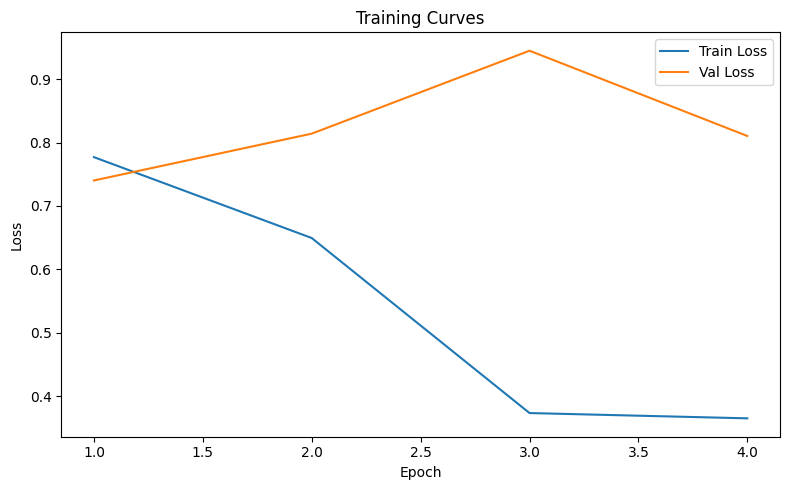

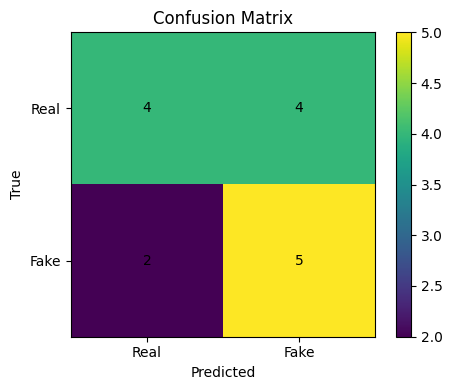


Saved outputs to: C:\deepfake
Done.


In [38]:
# =========================
# SINGLE-CELL JUPYTER CODE
# FaceForensics++_C23 binary deepfake detection
# original = real, all other folders = fake
# =========================

import os
import cv2
import json
import math
import time
import copy
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

warnings.filterwarnings("ignore", category=UserWarning)

# =========================
# 1. CONFIG
# =========================
DATA_ROOT = r"C:/Users/asus/Downloads/archive(2)/FaceForensics++_C23"
OUTPUT_DIR = r"C:/deepfake"

EPOCHS = 30
BATCH_SIZE = 4
FRAMES_PER_VIDEO = 32
IMG_SIZE = 160
LR = 2e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.3
HIDDEN_SIZE = 256
RNN_LAYERS = 1
NUM_WORKERS = 0
SEED = 42
VAL_SIZE = 0.15
TEST_SIZE = 0.15
EARLY_STOP_PATIENCE = 3
MAX_VIDEOS = None     # set 40 for quick debug

REAL_FOLDERS = ["original"]
FAKE_FOLDERS = [
    "NeuralTextures",
    "FaceSwap",
    "FaceShifter",
    "Face2Face",
    "Deepfakes",
    "DeepFakeDetection",
]

VIDEO_EXTS = {".mp4", ".avi", ".mov", ".mkv", ".webm", ".mpeg", ".mpg"}

# =========================
# 2. REPRODUCIBILITY
# =========================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

# =========================
# 3. UTILITIES
# =========================
def ensure_dir(path: Path):
    path.mkdir(parents=True, exist_ok=True)

def save_json(obj, path: Path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)

def is_video_file(path: Path) -> bool:
    return path.suffix.lower() in VIDEO_EXTS

def load_videos_from_ffpp_root(data_root: Path, real_folders, fake_folders):
    rows = []

    # show actual available folders
    available_dirs = [p.name for p in data_root.iterdir() if p.is_dir()]
    print("\nAvailable folders inside dataset root:")
    for d in available_dirs:
        print(repr(d))

    # helper for case-insensitive exact folder matching
    folder_map = {p.name.lower(): p for p in data_root.iterdir() if p.is_dir()}

    # real
    for folder_name in real_folders:
        folder_path = folder_map.get(folder_name.lower(), None)
        if folder_path is None:
            print(f"[Warning] Missing real folder: {folder_name}")
            continue

        for p in folder_path.rglob("*"):
            if p.is_file() and is_video_file(p):
                rows.append({
                    "video_path": str(p.resolve()),
                    "source_folder": folder_path.name,
                    "label_name": "real",
                    "label": 0,
                })

    # fake
    for folder_name in fake_folders:
        folder_path = folder_map.get(folder_name.lower(), None)
        if folder_path is None:
            print(f"[Warning] Missing fake folder: {folder_name}")
            continue

        for p in folder_path.rglob("*"):
            if p.is_file() and is_video_file(p):
                rows.append({
                    "video_path": str(p.resolve()),
                    "source_folder": folder_path.name,
                    "label_name": "fake",
                    "label": 1,
                })

    df = pd.DataFrame(rows)

    if df.empty:
        raise FileNotFoundError(
            f"No video files found under:\n{data_root}\n"
            f"Check whether videos are inside nested folders and whether extensions are supported."
        )

    return df

def stratified_video_split(df, seed=42, val_size=0.15, test_size=0.15):
    train_df, temp_df = train_test_split(
        df,
        test_size=val_size + test_size,
        stratify=df["label"],
        random_state=seed,
    )
    rel_test = test_size / (val_size + test_size)
    val_df, test_df = train_test_split(
        temp_df,
        test_size=rel_test,
        stratify=temp_df["label"],
        random_state=seed,
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)

def sample_frame_indices(num_frames, frames_per_video):
    if num_frames <= 0:
        return []
    if num_frames <= frames_per_video:
        return np.linspace(0, max(0, num_frames - 1), num_frames).astype(int).tolist()
    return np.linspace(0, num_frames - 1, frames_per_video).astype(int).tolist()

# =========================
# 4. FACE EXTRACTION
# =========================
class FastFaceExtractor:
    def __init__(self, img_size=224, margin=0.20):
        self.img_size = img_size
        self.margin = margin
        cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
        self.detector = cv2.CascadeClassifier(cascade_path)

    def extract_face(self, frame_bgr):
        gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
        faces = self.detector.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(50, 50),
        )

        h, w = frame_bgr.shape[:2]

        if len(faces) > 0:
            x, y, fw, fh = max(faces, key=lambda b: b[2] * b[3])
            mx = int(fw * self.margin)
            my = int(fh * self.margin)

            x1 = max(0, x - mx)
            y1 = max(0, y - my)
            x2 = min(w, x + fw + mx)
            y2 = min(h, y + fh + my)

            crop = frame_bgr[y1:y2, x1:x2]
        else:
            side = min(h, w)
            cx, cy = w // 2, h // 2
            half = side // 2
            y1, y2 = max(0, cy - half), min(h, cy + half)
            x1, x2 = max(0, cx - half), min(w, cx + half)
            crop = frame_bgr[y1:y2, x1:x2]

        crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        crop = cv2.resize(crop, (self.img_size, self.img_size), interpolation=cv2.INTER_AREA)
        return crop

def decode_video_frames(video_path, frames_per_video, face_extractor):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = sample_frame_indices(total_frames, frames_per_video)

    frames = []
    current_idx = 0
    pick_set = set(indices)

    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if current_idx in pick_set:
            face = face_extractor.extract_face(frame)
            frames.append(face)
            if len(frames) == len(indices):
                break
        current_idx += 1

    cap.release()

    if len(frames) == 0:
        raise RuntimeError(f"No frames decoded from video: {video_path}")

    while len(frames) < frames_per_video:
        frames.append(frames[-1].copy())

    return np.stack(frames[:frames_per_video], axis=0)

# =========================
# 5. DATASET
# =========================
class DeepfakeVideoDataset(Dataset):
    def __init__(self, df, cache_dir, frames_per_video=12, img_size=224, augment=False):
        self.df = df.reset_index(drop=True)
        self.cache_dir = Path(cache_dir)
        ensure_dir(self.cache_dir)
        self.frames_per_video = frames_per_video
        self.img_size = img_size
        self.face_extractor = FastFaceExtractor(img_size=img_size)
        self.augment = augment

        self.mean = [0.485, 0.456, 0.406]
        self.std = [0.229, 0.224, 0.225]

        self.base_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=self.mean, std=self.std),
        ])

        self.aug_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
            transforms.ToTensor(),
            transforms.Normalize(mean=self.mean, std=self.std),
        ])

    def __len__(self):
        return len(self.df)

    def _cache_path(self, video_path):
        safe_name = video_path.replace("\\", "_").replace("/", "_").replace(":", "")
        return self.cache_dir / f"{safe_name}__f{self.frames_per_video}_s{self.img_size}.npy"

    def _load_or_build_frames(self, video_path):
        cpath = self._cache_path(video_path)
        if cpath.exists():
            return np.load(cpath)
        arr = decode_video_frames(video_path, self.frames_per_video, self.face_extractor)
        np.save(cpath, arr)
        return arr

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        video_path = row["video_path"]
        label = int(row["label"])

        frames = self._load_or_build_frames(video_path)

        tensors = []
        for i in range(frames.shape[0]):
            img = frames[i]
            if self.augment:
                tensor = self.aug_transform(img)
            else:
                tensor = self.base_transform(img)
            tensors.append(tensor)

        x = torch.stack(tensors, dim=0)   # [T,C,H,W]
        y = torch.tensor(label, dtype=torch.long)
        return x, y, video_path

# =========================
# 6. MODEL
# =========================
class ResNetGRU(nn.Module):
    def __init__(self, hidden_size=256, num_layers=1, bidirectional=True, dropout=0.2):
        super().__init__()

        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        feat_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone

        self.gru = nn.GRU(
            input_size=feat_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=0.0 if num_layers == 1 else dropout,
        )

        out_dim = hidden_size * (2 if bidirectional else 1)

        self.head = nn.Sequential(
            nn.LayerNorm(out_dim),
            nn.Dropout(dropout),
            nn.Linear(out_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        b, t, c, h, w = x.shape
        x = x.view(b * t, c, h, w)
        feat = self.backbone(x)
        feat = feat.view(b, t, -1)
        seq_out, _ = self.gru(feat)
        pooled = seq_out.mean(dim=1)
        logits = self.head(pooled)
        return logits

# =========================
# 7. TRAIN / EVAL
# =========================
def make_class_weights(labels):
    cnt = Counter(labels)
    total = sum(cnt.values())
    weights = []
    for cls in [0, 1]:
        weights.append(total / max(1, cnt.get(cls, 1)))
    w = torch.tensor(weights, dtype=torch.float32)
    return w / w.sum() * len(weights)

def get_device():
    return "cuda" if torch.cuda.is_available() else "cpu"

def compute_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    try:
        auc = roc_auc_score(y_true, y_prob)
    except Exception:
        auc = float("nan")
    return {
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "auc": float(auc) if not math.isnan(auc) else None,
    }

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    losses = []
    all_true, all_pred, all_prob, all_paths = [], [], [], []

    for x, y, paths in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)
        prob = torch.softmax(logits, dim=1)[:, 1]
        pred = torch.argmax(logits, dim=1)

        losses.append(loss.item())
        all_true.extend(y.cpu().numpy().tolist())
        all_pred.extend(pred.cpu().numpy().tolist())
        all_prob.extend(prob.cpu().numpy().tolist())
        all_paths.extend(list(paths))

    metrics = compute_metrics(all_true, all_pred, all_prob)
    metrics["loss"] = float(np.mean(losses)) if losses else None
    return metrics, all_true, all_pred, all_prob, all_paths

def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    losses = []

    for x, y, _ in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device == "cuda")):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        losses.append(loss.item())

    return float(np.mean(losses)) if losses else None

def plot_history(history, out_path: Path):
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Curves")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

def plot_confusion(y_true, y_pred, out_path: Path):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ["Real", "Fake"])
    plt.yticks(tick_marks, ["Real", "Fake"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, int(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

def save_predictions(paths, y_true, y_pred, y_prob, out_path: Path):
    df = pd.DataFrame({
        "video_path": paths,
        "true_label": y_true,
        "pred_label": y_pred,
        "fake_probability": y_prob,
    })
    df.to_csv(out_path, index=False)

def print_split_summary(train_df, val_df, test_df):
    print("\nSplit Summary")
    print("-" * 60)
    for name, df_ in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
        cnt = df_["label_name"].value_counts().to_dict()
        src = df_["source_folder"].value_counts().to_dict()
        print(f"{name}: {len(df_)} videos | label distribution = {cnt}")
        print(f"{name}: source folders = {src}")

def build_loaders(train_df, val_df, test_df):
    train_ds = DeepfakeVideoDataset(
        train_df,
        cache_dir=Path(OUTPUT_DIR) / "cache" / "train",
        frames_per_video=FRAMES_PER_VIDEO,
        img_size=IMG_SIZE,
        augment=True,
    )
    val_ds = DeepfakeVideoDataset(
        val_df,
        cache_dir=Path(OUTPUT_DIR) / "cache" / "val",
        frames_per_video=FRAMES_PER_VIDEO,
        img_size=IMG_SIZE,
        augment=False,
    )
    test_ds = DeepfakeVideoDataset(
        test_df,
        cache_dir=Path(OUTPUT_DIR) / "cache" / "test",
        frames_per_video=FRAMES_PER_VIDEO,
        img_size=IMG_SIZE,
        augment=False,
    )

    common = dict(
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    train_loader = DataLoader(train_ds, shuffle=True, **common)
    val_loader = DataLoader(val_ds, shuffle=False, **common)
    test_loader = DataLoader(test_ds, shuffle=False, **common)
    return train_loader, val_loader, test_loader

# =========================
# 8. RUN
# =========================
output_dir = Path(OUTPUT_DIR)
ensure_dir(output_dir)
ensure_dir(output_dir / "models")
ensure_dir(output_dir / "plots")

print(f"Loading FaceForensics++ dataset from: {DATA_ROOT}")
df = load_videos_from_ffpp_root(Path(DATA_ROOT), REAL_FOLDERS, FAKE_FOLDERS)

print("\nOverall dataset summary")
print(df["label_name"].value_counts())
print("\nBy source folder")
print(df["source_folder"].value_counts())

if MAX_VIDEOS is not None and MAX_VIDEOS > 0:
    sampled = []
    for label in [0, 1]:
        part = df[df["label"] == label].sample(
            n=min(MAX_VIDEOS // 2, (df["label"] == label).sum()),
            random_state=SEED,
        )
        sampled.append(part)
    df = pd.concat(sampled).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

train_df, val_df, test_df = stratified_video_split(
    df, seed=SEED, val_size=VAL_SIZE, test_size=TEST_SIZE
)

train_df.to_csv(output_dir / "train_split.csv", index=False)
val_df.to_csv(output_dir / "val_split.csv", index=False)
test_df.to_csv(output_dir / "test_split.csv", index=False)

print_split_summary(train_df, val_df, test_df)

train_loader, val_loader, test_loader = build_loaders(train_df, val_df, test_df)

device = get_device()
print(f"\nUsing device: {device}")

model = ResNetGRU(
    hidden_size=HIDDEN_SIZE,
    num_layers=RNN_LAYERS,
    bidirectional=True,
    dropout=DROPOUT,
).to(device)

class_weights = make_class_weights(train_df["label"].tolist()).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))

best_f1 = -1.0
best_state = None
history = {"train_loss": [], "val_loss": [], "val_f1": []}
patience_counter = 0

print("\nStarting training...")
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, scaler, device)
    val_metrics, _, _, _, _ = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_f1"].append(val_metrics["f1"])

    elapsed = time.time() - t0
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_acc={val_metrics['accuracy']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f} | "
        f"val_auc={val_metrics['auc']} | "
        f"time={elapsed:.1f}s"
    )

    if val_metrics["f1"] > best_f1:
        best_f1 = val_metrics["f1"]
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, output_dir / "models" / "best_model.pt")
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"Early stopping triggered after {epoch} epochs.")
        break

if best_state is None:
    raise RuntimeError("Training did not produce a best model.")

model.load_state_dict(best_state)

val_metrics, val_true, val_pred, val_prob, val_paths = evaluate(model, val_loader, criterion, device)
test_metrics, test_true, test_pred, test_prob, test_paths = evaluate(model, test_loader, criterion, device)

print("\nValidation Metrics")
print(json.dumps(val_metrics, indent=2))

print("\nTest Metrics")
print(json.dumps(test_metrics, indent=2))

report = classification_report(test_true, test_pred, target_names=["real", "fake"], zero_division=0)
print("\nTest Classification Report")
print(report)

save_json(
    {
        "config": {
            "DATA_ROOT": DATA_ROOT,
            "OUTPUT_DIR": OUTPUT_DIR,
            "EPOCHS": EPOCHS,
            "BATCH_SIZE": BATCH_SIZE,
            "FRAMES_PER_VIDEO": FRAMES_PER_VIDEO,
            "IMG_SIZE": IMG_SIZE,
            "LR": LR,
            "WEIGHT_DECAY": WEIGHT_DECAY,
            "DROPOUT": DROPOUT,
            "HIDDEN_SIZE": HIDDEN_SIZE,
            "RNN_LAYERS": RNN_LAYERS,
            "NUM_WORKERS": NUM_WORKERS,
            "SEED": SEED,
            "VAL_SIZE": VAL_SIZE,
            "TEST_SIZE": TEST_SIZE,
            "EARLY_STOP_PATIENCE": EARLY_STOP_PATIENCE,
            "MAX_VIDEOS": MAX_VIDEOS,
            "REAL_FOLDERS": REAL_FOLDERS,
            "FAKE_FOLDERS": FAKE_FOLDERS,
        },
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "best_val_f1": best_f1,
    },
    output_dir / "metrics.json",
)

save_predictions(val_paths, val_true, val_pred, val_prob, output_dir / "val_predictions.csv")
save_predictions(test_paths, test_true, test_pred, test_prob, output_dir / "test_predictions.csv")
plot_history(history, output_dir / "plots" / "training_curves.png")
plot_confusion(test_true, test_pred, output_dir / "plots" / "confusion_matrix.png")

with open(output_dir / "classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

print(f"\nSaved outputs to: {output_dir.resolve()}")
print("Done.")

For incremental level 100 real 100 fake 


In [1]:
# =========================
# SINGLE-CELL JUPYTER CODE
# FAST + STRONGER FF++ BINARY DEEPFAKE DETECTION
# Honest video-level split
# Center-crop face region for FF++ (faster and more stable than Haar here)
# One-time cache + MobileNetV3 + temporal attention
# =========================

import os
import cv2
import json
import math
import time
import copy
import random
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

warnings.filterwarnings("ignore", category=UserWarning)

# =========================
# 1. CONFIG
# =========================
DATA_ROOT = Path(r"C:/Users/asus/Downloads/archive(2)/FaceForensics++_C23")
OUTPUT_DIR = Path(r"C:/deepfake/ffpp_fast_strong")

REAL_FOLDERS = ["original"]
FAKE_FOLDERS = [
    "NeuralTextures",
    "FaceSwap",
    "FaceShifter",
    "Face2Face",
    "Deepfakes",
    "DeepFakeDetection",
]

VIDEO_EXTS = {".mp4", ".avi", ".mov", ".mkv", ".webm", ".mpeg", ".mpg"}

# speed / quality tradeoff
IMG_SIZE = 128
FRAMES_PER_VIDEO = 8
EPOCHS = 8
BATCH_SIZE = 8
LR = 3e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.25
HIDDEN_SIZE = 128
RNN_LAYERS = 1
NUM_WORKERS = 0
SEED = 42
VAL_SIZE = 0.15
TEST_SIZE = 0.15
EARLY_STOP_PATIENCE = 3

# sample settings
MAX_TOTAL_VIDEOS = 200      # 100 real + 100 fake for your case
BALANCE_FAKE_SOURCES = True # spread fake samples across manipulation types
FORCE_REBUILD_CACHE = False

# crop settings for FF++
CENTER_CROP_SCALE = 0.70    # face-focused central crop
USE_CENTER_CROP = True      # recommended for FF++
USE_HAAR_FALLBACK = False   # keep False for speed

# train settings
LABEL_SMOOTHING = 0.05
FREEZE_BACKBONE_EPOCHS = 2  # freeze first few epochs, then unfreeze

# =========================
# 2. REPRODUCIBILITY
# =========================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

# =========================
# 3. UTILITIES
# =========================
def ensure_dir(path: Path):
    path.mkdir(parents=True, exist_ok=True)

def save_json(obj, path: Path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)

def is_video_file(path: Path) -> bool:
    return path.suffix.lower() in VIDEO_EXTS

def get_device():
    return "cuda" if torch.cuda.is_available() else "cpu"

def save_predictions(paths, y_true, y_pred, y_prob, out_path: Path):
    df = pd.DataFrame({
        "video_path": paths,
        "true_label": y_true,
        "pred_label": y_pred,
        "fake_probability": y_prob,
    })
    df.to_csv(out_path, index=False)

def plot_history(history, out_path: Path):
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.plot(epochs, history["val_f1"], label="Val F1")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title("Training History")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

def plot_confusion(y_true, y_pred, out_path: Path):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix")
    plt.colorbar()
    ticks = np.arange(2)
    plt.xticks(ticks, ["Real", "Fake"])
    plt.yticks(ticks, ["Real", "Fake"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, int(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

def compute_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    try:
        auc = roc_auc_score(y_true, y_prob)
    except Exception:
        auc = None
    return {
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "auc": float(auc) if auc is not None else None,
    }

def make_class_weights(labels):
    cnt = Counter(labels)
    total = sum(cnt.values())
    weights = []
    for cls in [0, 1]:
        weights.append(total / max(1, cnt.get(cls, 1)))
    w = torch.tensor(weights, dtype=torch.float32)
    return w / w.sum() * len(weights)

def print_split_summary(train_df, val_df, test_df):
    print("\nSplit Summary")
    for name, df_ in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
        print(f"{name}: {len(df_)}")
        print(" labels:", df_["label_name"].value_counts().to_dict())
        print(" sources:", df_["source_folder"].value_counts().to_dict())

# =========================
# 4. LOAD DATASET
# =========================
def load_videos_from_ffpp_root(data_root: Path, real_folders, fake_folders):
    rows = []
    folder_map = {p.name.lower(): p for p in data_root.iterdir() if p.is_dir()}

    print("Available folders:")
    for k in sorted(folder_map.keys()):
        print(" -", folder_map[k].name)

    for folder_name in real_folders:
        folder_path = folder_map.get(folder_name.lower())
        if folder_path is None:
            print(f"[Warning] Missing real folder: {folder_name}")
            continue
        for p in folder_path.rglob("*"):
            if p.is_file() and is_video_file(p):
                rows.append({
                    "video_path": str(p.resolve()),
                    "source_folder": folder_path.name,
                    "label_name": "real",
                    "label": 0,
                })

    for folder_name in fake_folders:
        folder_path = folder_map.get(folder_name.lower())
        if folder_path is None:
            print(f"[Warning] Missing fake folder: {folder_name}")
            continue
        for p in folder_path.rglob("*"):
            if p.is_file() and is_video_file(p):
                rows.append({
                    "video_path": str(p.resolve()),
                    "source_folder": folder_path.name,
                    "label_name": "fake",
                    "label": 1,
                })

    df = pd.DataFrame(rows)
    if df.empty:
        raise FileNotFoundError(f"No videos found under {data_root}")
    return df

def balanced_subset_ffpp(df, total_videos=200, seed=42, balance_fake_sources=True):
    real_target = total_videos // 2
    fake_target = total_videos // 2

    real_df = df[df["label"] == 0].sample(
        n=min(real_target, (df["label"] == 0).sum()),
        random_state=seed
    )

    fake_df_all = df[df["label"] == 1].copy()

    if not balance_fake_sources:
        fake_df = fake_df_all.sample(
            n=min(fake_target, len(fake_df_all)),
            random_state=seed
        )
    else:
        per_source = max(1, fake_target // max(1, fake_df_all["source_folder"].nunique()))
        chosen = []
        rng_seed = seed
        for src, part in fake_df_all.groupby("source_folder"):
            n_take = min(per_source, len(part))
            chosen.append(part.sample(n=n_take, random_state=rng_seed))
            rng_seed += 1
        fake_df = pd.concat(chosen, axis=0)

        # fill remaining slots if needed
        remaining = fake_target - len(fake_df)
        if remaining > 0:
            leftover = fake_df_all.loc[~fake_df_all.index.isin(fake_df.index)]
            if len(leftover) > 0:
                extra = leftover.sample(n=min(remaining, len(leftover)), random_state=seed + 99)
                fake_df = pd.concat([fake_df, extra], axis=0)

        # trim in case slightly over
        if len(fake_df) > fake_target:
            fake_df = fake_df.sample(n=fake_target, random_state=seed)

    out = pd.concat([real_df, fake_df], axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out

def stratified_video_split(df, seed=42, val_size=0.15, test_size=0.15):
    train_df, temp_df = train_test_split(
        df,
        test_size=val_size + test_size,
        stratify=df["label"],
        random_state=seed,
    )
    rel_test = test_size / (val_size + test_size)
    val_df, test_df = train_test_split(
        temp_df,
        test_size=rel_test,
        stratify=temp_df["label"],
        random_state=seed,
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)

# =========================
# 5. FRAME EXTRACTION
# =========================
class FFPlusCropper:
    def __init__(self, img_size=128, crop_scale=0.70, use_center_crop=True, use_haar_fallback=False):
        self.img_size = img_size
        self.crop_scale = crop_scale
        self.use_center_crop = use_center_crop
        self.use_haar_fallback = use_haar_fallback
        if self.use_haar_fallback:
            cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
            self.detector = cv2.CascadeClassifier(cascade_path)
        else:
            self.detector = None

    def center_crop_face(self, frame_bgr):
        h, w = frame_bgr.shape[:2]
        side = int(min(h, w) * self.crop_scale)
        cx, cy = w // 2, h // 2
        x1 = max(0, cx - side // 2)
        y1 = max(0, cy - side // 2)
        x2 = min(w, x1 + side)
        y2 = min(h, y1 + side)
        crop = frame_bgr[y1:y2, x1:x2]
        crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        crop = cv2.resize(crop, (self.img_size, self.img_size), interpolation=cv2.INTER_AREA)
        return crop

    def haar_crop_face(self, frame_bgr):
        gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
        faces = self.detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40))
        h, w = frame_bgr.shape[:2]
        if len(faces) > 0:
            x, y, fw, fh = max(faces, key=lambda b: b[2] * b[3])
            m = int(max(fw, fh) * 0.20)
            x1 = max(0, x - m)
            y1 = max(0, y - m)
            x2 = min(w, x + fw + m)
            y2 = min(h, y + fh + m)
            crop = frame_bgr[y1:y2, x1:x2]
            crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
            crop = cv2.resize(crop, (self.img_size, self.img_size), interpolation=cv2.INTER_AREA)
            return crop
        return self.center_crop_face(frame_bgr)

    def extract_face(self, frame_bgr):
        if self.use_center_crop:
            return self.center_crop_face(frame_bgr)
        return self.haar_crop_face(frame_bgr)

def sample_frame_indices(num_frames, frames_per_video):
    if num_frames <= 0:
        return []
    return np.linspace(0, max(0, num_frames - 1), min(frames_per_video, max(1, num_frames))).astype(int).tolist()

def make_cache_path(video_path: str, cache_dir: Path, frames_per_video: int, img_size: int):
    safe_name = video_path.replace("\\", "_").replace("/", "_").replace(":", "")
    return cache_dir / f"{safe_name}__f{frames_per_video}_s{img_size}.npy"

def decode_video_frames(video_path, frames_per_video, cropper):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = sample_frame_indices(total_frames, frames_per_video)
    pick_set = set(indices)

    frames = []
    current_idx = 0

    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if current_idx in pick_set:
            frames.append(cropper.extract_face(frame))
            if len(frames) == len(indices):
                break
        current_idx += 1

    cap.release()

    if len(frames) == 0:
        raise RuntimeError(f"No frames decoded from video: {video_path}")

    while len(frames) < frames_per_video:
        frames.append(frames[-1].copy())

    return np.stack(frames[:frames_per_video], axis=0)

def precompute_cache(df, cache_dir, frames_per_video=8, img_size=128, force_rebuild=False):
    ensure_dir(cache_dir)
    cropper = FFPlusCropper(
        img_size=img_size,
        crop_scale=CENTER_CROP_SCALE,
        use_center_crop=USE_CENTER_CROP,
        use_haar_fallback=USE_HAAR_FALLBACK
    )

    cache_paths = []
    failed = 0
    t0 = time.time()

    for i, row in enumerate(df.itertuples(index=False), start=1):
        video_path = row.video_path
        cpath = make_cache_path(video_path, cache_dir, frames_per_video, img_size)
        try:
            if force_rebuild or not cpath.exists():
                arr = decode_video_frames(video_path, frames_per_video, cropper)
                np.save(cpath, arr)
            cache_paths.append(str(cpath.resolve()))
        except Exception:
            cache_paths.append(None)
            failed += 1

        if i % 25 == 0 or i == len(df):
            print(f"Cache {i}/{len(df)} | failed={failed} | elapsed={(time.time()-t0)/60:.1f} min")

    out = df.copy()
    out["cache_path"] = cache_paths
    out = out.dropna(subset=["cache_path"]).reset_index(drop=True)
    return out

# =========================
# 6. DATASET
# =========================
class CachedVideoDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment

        self.mean = [0.485, 0.456, 0.406]
        self.std = [0.229, 0.224, 0.225]

        self.base_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=self.mean, std=self.std),
        ])

        self.aug_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.05, hue=0.01),
            transforms.ToTensor(),
            transforms.Normalize(mean=self.mean, std=self.std),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        frames = np.load(row["cache_path"])  # [T,H,W,C]
        label = int(row["label"])

        tensors = []
        for i in range(frames.shape[0]):
            img = frames[i]
            tensor = self.aug_transform(img) if self.augment else self.base_transform(img)
            tensors.append(tensor)

        x = torch.stack(tensors, dim=0)
        y = torch.tensor(label, dtype=torch.long)
        return x, y, row["video_path"]

def build_loaders(train_df, val_df, test_df):
    train_ds = CachedVideoDataset(train_df, augment=True)
    val_ds = CachedVideoDataset(val_df, augment=False)
    test_ds = CachedVideoDataset(test_df, augment=False)

    common = dict(
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    train_loader = DataLoader(train_ds, shuffle=True, **common)
    val_loader = DataLoader(val_ds, shuffle=False, **common)
    test_loader = DataLoader(test_ds, shuffle=False, **common)
    return train_loader, val_loader, test_loader

# =========================
# 7. MODEL
# =========================
class TemporalAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(dim, dim // 2),
            nn.Tanh(),
            nn.Linear(dim // 2, 1)
        )

    def forward(self, x):
        # x: [B,T,D]
        w = torch.softmax(self.score(x), dim=1)  # [B,T,1]
        pooled = (x * w).sum(dim=1)
        return pooled

class MobileNetV3Temporal(nn.Module):
    def __init__(self, hidden_size=128, dropout=0.25):
        super().__init__()

        backbone = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V2)
        self.features = backbone.features
        self.pool2d = nn.AdaptiveAvgPool2d((1, 1))
        feat_dim = 960

        self.temporal = nn.GRU(
            input_size=feat_dim,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        out_dim = hidden_size * 2
        self.attn = TemporalAttention(out_dim)

        self.head = nn.Sequential(
            nn.LayerNorm(out_dim),
            nn.Dropout(dropout),
            nn.Linear(out_dim, 128),
            nn.Hardswish(),
            nn.Dropout(dropout),
            nn.Linear(128, 2),
        )

    def freeze_backbone(self, freeze=True):
        for p in self.features.parameters():
            p.requires_grad = not freeze

    def forward(self, x):
        # x [B,T,C,H,W]
        b, t, c, h, w = x.shape
        x = x.view(b * t, c, h, w)
        feat = self.features(x)
        feat = self.pool2d(feat).flatten(1)
        feat = feat.view(b, t, -1)
        seq_out, _ = self.temporal(feat)
        pooled = self.attn(seq_out)
        logits = self.head(pooled)
        return logits

# =========================
# 8. TRAIN / EVAL
# =========================
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    losses = []
    all_true, all_pred, all_prob, all_paths = [], [], [], []

    for x, y, paths in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)
        prob = torch.softmax(logits, dim=1)[:, 1]
        pred = torch.argmax(logits, dim=1)

        losses.append(loss.item())
        all_true.extend(y.cpu().numpy().tolist())
        all_pred.extend(pred.cpu().numpy().tolist())
        all_prob.extend(prob.cpu().numpy().tolist())
        all_paths.extend(list(paths))

    metrics = compute_metrics(all_true, all_pred, all_prob)
    metrics["loss"] = float(np.mean(losses)) if losses else None
    return metrics, all_true, all_pred, all_prob, all_paths

def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    losses = []

    for x, y, _ in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if device == "cuda":
            with torch.cuda.amp.autocast():
                logits = model(x)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

        losses.append(loss.item())

    return float(np.mean(losses)) if losses else None

# =========================
# 9. RUN
# =========================
ensure_dir(OUTPUT_DIR)
ensure_dir(OUTPUT_DIR / "plots")
ensure_dir(OUTPUT_DIR / "models")
ensure_dir(OUTPUT_DIR / "cache_raw")

print(f"Loading dataset from: {DATA_ROOT}")
df_all = load_videos_from_ffpp_root(DATA_ROOT, REAL_FOLDERS, FAKE_FOLDERS)

print("\nOverall dataset summary")
print(df_all["label_name"].value_counts())
print("\nBy source folder")
print(df_all["source_folder"].value_counts())

# balanced subset
if MAX_TOTAL_VIDEOS is not None and MAX_TOTAL_VIDEOS > 0:
    df = balanced_subset_ffpp(
        df_all,
        total_videos=MAX_TOTAL_VIDEOS,
        seed=SEED,
        balance_fake_sources=BALANCE_FAKE_SOURCES
    )
else:
    df = df_all.copy()

print("\nSubset summary")
print(df["label_name"].value_counts())
print(df["source_folder"].value_counts())

# split first, then cache only used samples
train_df, val_df, test_df = stratified_video_split(
    df, seed=SEED, val_size=VAL_SIZE, test_size=TEST_SIZE
)
print_split_summary(train_df, val_df, test_df)

# cache once
train_df = precompute_cache(
    train_df, OUTPUT_DIR / "cache_raw" / "train",
    frames_per_video=FRAMES_PER_VIDEO, img_size=IMG_SIZE,
    force_rebuild=FORCE_REBUILD_CACHE
)
val_df = precompute_cache(
    val_df, OUTPUT_DIR / "cache_raw" / "val",
    frames_per_video=FRAMES_PER_VIDEO, img_size=IMG_SIZE,
    force_rebuild=FORCE_REBUILD_CACHE
)
test_df = precompute_cache(
    test_df, OUTPUT_DIR / "cache_raw" / "test",
    frames_per_video=FRAMES_PER_VIDEO, img_size=IMG_SIZE,
    force_rebuild=FORCE_REBUILD_CACHE
)

train_df.to_csv(OUTPUT_DIR / "train_split.csv", index=False)
val_df.to_csv(OUTPUT_DIR / "val_split.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "test_split.csv", index=False)

train_loader, val_loader, test_loader = build_loaders(train_df, val_df, test_df)

device = get_device()
print(f"\nUsing device: {device}")

model = MobileNetV3Temporal(hidden_size=HIDDEN_SIZE, dropout=DROPOUT).to(device)
model.freeze_backbone(True)

class_weights = make_class_weights(train_df["label"].tolist()).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
sc

Loading dataset from: C:\Users\asus\Downloads\archive(2)\FaceForensics++_C23
Available folders:
 - DeepFakeDetection
 - Deepfakes
 - Face2Face
 - FaceShifter
 - FaceSwap
 - NeuralTextures
 - original

Overall dataset summary
label_name
fake    6000
real    1000
Name: count, dtype: int64

By source folder
source_folder
original             1000
NeuralTextures       1000
FaceSwap             1000
FaceShifter          1000
Face2Face            1000
Deepfakes            1000
DeepFakeDetection    1000
Name: count, dtype: int64

Subset summary
label_name
real    100
fake    100
Name: count, dtype: int64
source_folder
original             100
NeuralTextures        18
FaceShifter           17
Face2Face             17
Deepfakes             16
DeepFakeDetection     16
FaceSwap              16
Name: count, dtype: int64

Split Summary
Train: 140
 labels: {'real': 70, 'fake': 70}
 sources: {'original': 70, 'DeepFakeDetection': 13, 'Deepfakes': 12, 'Face2Face': 12, 'NeuralTextures': 11, 'FaceSwap': 

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to C:\Users\asus/.cache\torch\hub\checkpoints\mobilenet_v3_large-5c1a4163.pth
100%|██████████| 21.1M/21.1M [00:07<00:00, 3.04MB/s]


NameError: name 'sc' is not defined